In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from IPython.display import display, Markdown

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [2]:
df = pd.read_excel("../../data_raw/DataSet_V49 (2).xlsx")

print(f"Данные успешно загружены! Размер: {df.shape}")
print(f"Занимаемая память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Данные успешно загружены! Размер: (17430, 465)
Занимаемая память: 189.51 MB


In [108]:
print(list(df.columns))

['Код пациента', 'Name', 'Age', 'Sex', 'Наличие в БД', 'Наличие в файле', 'STEMI', 'ЧКВ', 'Дата STEMI', 'Вид STEMI', 'SYNTAX Score', 'Инфаркт-зависимая артерия', 'Поражение ствола', 'Количество пораженных сосудов(Syntax)', 'Количество пораженных сосудов(Значимость)', 'TIMI', 'Инфаркт миокарда в анамнезе (<3)', 'Инфаркт миокарда в анамнезе (>3)', 'Инфаркт миокарда со стентированием в анамнезе', 'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе', 'Стентирование в анамнезе', 'Тромболизис', 'Форма ФП', 'Калий', 'Дилатация предсердий', 'ФП b (после чкв)', 'ФП a (в анамнезе)', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ', 'Пробежки ЖТ', 'Рецидивирующая ЖТ', 'MKB', 'Класс ОСН по Killip', 'ХСН стадия', 'ХСН фк', 'ГБ стадия', 'ГБ риск', 'АГ', 'Стенокардия (ИБ)', 'Стенокардия форма(ИБ)', 'Стенокардия ФК (ИБ)', 'СД', 'ХБП', 'ЯБ', 'МКБ', 'ЖКБ', 'ФВ ЛЖ (b)', 'ФВ ЛЖ', 'EDV', 'КДР ЛЖ', 'КСР ЛЖ', 'МЖП', 'ЗСЛЖ', 'ПСПЖ', 'СДЛА', 'Размер правого желудочка', 'Стеноз аортального клапана (степень)', 'Нед

In [3]:
# Базовая информация о данных
display(Markdown("## 📊 Базовая информация о датасете"))

# Информация о типах данных
display(Markdown("### 💾 Информация о типах данных"))
buffer = pd.io.common.StringIO()
df.info(buf=buffer)
info_str = buffer.getvalue()
display(Markdown(f"```\n{info_str}\n```"))

info_df = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.astype(str),
    'First Value': df.iloc[0].values,
    'Last Value': df.iloc[-1].values,
    'Unique Values': df.nunique().values
})

# Красивое отображение в Jupyter
display(info_df.style
        .set_caption("DataFrame Schema Overview")
        .format(precision=2)
        .background_gradient(cmap='Blues', subset=['Unique Values']))

# Описательная статистика
display(Markdown("### 📈 Описательная статистика числовых признаков"))
display(df.describe().T.style.background_gradient(cmap='viridis'))

# Первые и последние строки
display(Markdown("### 👀 Первые 5 строк данных"))
display(df.head())

display(Markdown("### 👀 Последние 5 строк данных"))
display(df.tail())

# Уникальные значения для категориальных признаков (первые 10 столбцов)
display(Markdown("### 🔍 Анализ уникальных значений (первые 10 столбцов)"))
unique_counts = {}
for col in df.columns[:10]:
    unique_counts[col] = {
        'unique_count': df[col].nunique(),
        'unique_values': df[col].unique()[:10].tolist(),
        'dtype': str(df[col].dtype)
    }

unique_df = pd.DataFrame(unique_counts).T
display(unique_df)

## 📊 Базовая информация о датасете

### 💾 Информация о типах данных

```
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17430 entries, 0 to 17429
Columns: 465 entries, Код пациента to BNP
dtypes: datetime64[ns](3), float64(302), object(160)
memory usage: 61.8+ MB

```

,Column,Type,First Value,Last Value,Unique Values
Код пациента,Код пациента,object,20-6545,2024-04-19 00:00:00,17326
Name,Name,object,Хасьянов РА,Петров ВЮ,14678
Age,Age,float64,78.00,53.00,79
Sex,Sex,object,М,М,2
Наличие в БД,Наличие в БД,object,Да,Да,2
Наличие в файле,Наличие в файле,object,Да,Да,2
STEMI,STEMI,object,Нет,Да,2
ЧКВ,ЧКВ,object,Да,Да,2
Дата STEMI,Дата STEMI,object,nan,2018-12-31 00:00:00,2502
Вид STEMI,Вид STEMI,object,nan,Задний,2


### 📈 Описательная статистика числовых признаков

...

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
0,20-6545,Хасьянов РА,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,-5.0,18.5,18.5,18.5,18.5,18.5,18.5,NaN,NaN,NaN
1,19-22109,Тюркова ГГ,80.0,Ж,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17-13439,Ремизов РВ,40.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,16-20326,Синенко ОП,78.0,М,Да,Да,Нет,Да,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,9993,Комолов ВИ,75.0,М,Да,Да,Да,Да,2015-07-09 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 👀 Последние 5 строк данных

,Код пациента,Name,Age,Sex,Наличие в БД,Наличие в файле,STEMI,ЧКВ,Дата STEMI,Вид STEMI,...,BEVenMax,HCO3VenMin (b),HCO3VenMin (a),HCO3VenMin,HCO3VenMax (b),HCO3VenMax (a),HCO3VenMax,BNP (b),BNP (a),BNP
17425,10019,Гаевский АИ,60.0,М,Да,Да,Да,Да,2021-06-08 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17426,10,Сальникова ВС,81.0,Ж,Да,Да,Да,Да,2020-12-31 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17427,1,Халиман ОА,48.0,М,Да,Да,Да,Да,2020-01-01 00:00:00,Передний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17428,2024-06-18 00:00:00,Журавлев АЮ,50.0,М,Да,Да,Да,Да,2018-01-01 00:00:00,Задний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17429,2024-04-19 00:00:00,Петров ВЮ,53.0,М,Да,Да,Да,Да,2018-12-31 00:00:00,Задний,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 🔍 Анализ уникальных значений (первые 10 столбцов)

,unique_count,unique_values,dtype
Код пациента,17326,"[20-6545, 19-22109, 17-13439, 16-20326, 9993, ...",object
Name,14678,"[Хасьянов РА, Тюркова ГГ, Ремизов РВ, Синенко ...",object
Age,79,"[78.0, 80.0, 40.0, 75.0, 61.0, 69.0, 67.0, 49....",float64
Sex,2,"[М, Ж, nan]",object
Наличие в БД,2,"[Да, Нет, nan]",object
Наличие в файле,2,"[Да, Нет, nan]",object
STEMI,2,"[Нет, Да, nan]",object
ЧКВ,2,"[Да, Нет, nan]",object
Дата STEMI,2502,"[nan, 2015-07-09 00:00:00, 2015-07-06 00:00:00...",object
Вид STEMI,2,"[nan, Передний, Задний]",object


------------------

In [4]:
target_variable = 'Смерть'
df[target_variable] = df['Смерть'].map({'Да': 1, 'Нет': 0})

In [109]:
# СПИСОК БЕЗОПАСНЫХ ПРИЗНАКОВ (можно использовать для прогнозирования при поступлении):
safe_features = [
    # Демография
    'Age', 'Sex', 'Рост', 'Вес', 'Индекс массы тела',
    
    # Анамнез
    'Инфаркт миокарда в анамнезе (<3)', 'Инфаркт миокарда в анамнезе (>3)',
    'ОНМК (иш) в анамнезе', 'ОНМК (гем) в анамнезе', 'Стентирование в анамнезе',
    'ГБ стадия', 'ГБ риск', 'АГ', 'СД', 'ХБП', 'Курит',
    'Экстракардиальная артериопатия', 'Плохая мобильность',
    
    # Клинические признаки при поступлении
    'STEMI', 'Вид STEMI', 'Класс ОСН по Killip', 'TIMI',  # только если рассчитаны при поступлении
    'Систолическое АД(b)', 'Диастолического АД(b)', 'ЧСС (b)', 'SpO2',
    'P', 'PQ', 'QRS', 'QT', 'RR',  # ЭКГ при поступлении
    
    # Лабораторные анализы при поступлении (суффикс b)
    'Калий (K) (b)', 'Натрий (Na) (b)', 'Хлор (Cl) (b)', 'Кальций ионизированный (Ca+) (b)',
    'Гемоглобин(b)', 'Лейкоциты(b)', 'Тромбоциты(b)', 'Креатинин(b)', 'Мочевина(b)',
    'Тропонин 1 (b)', 'Тропонин 1 > 0.1 (b)', 'BNP (b)',
    'pHARTmin (b)', 'pO2ARTmin (b)', 'LACTartMin (b)', 'LACTartMax (b)',
    
    # Инструментальные исследования (если известны из анамнеза)
    'ФВ ЛЖ(b)', 'Стеноз аортального клапана (степень)', 'Недостаточность митрального клапана (степень)', 

    'Смерть'
]

In [5]:
cols_to_delete_old = [
    "Код пациента", "Name", "Дата STEMI", "Дата направления (Общий анализ крови)", 
    "Дата взятия биоматериала (Общий анализ крови)", "Дата выполнения (Общий анализ крови)", 
    "Дата направления (Общий анализ крови-экспрес)", "Дата взятия биоматериала (Общий анализ крови-экспрес)",
    "Дата выполнения (Общий анализ крови-экспрес)", "Начало операции(ИБ)(Новый)", "Конец операции(ИБ)(Новый)", 
    "дата поступления", "дата выписки", "дата смерти", "Исход заболевания", "Поступление в реанимацию", 
    "Выписка из реанимации", "Файл(Анализы)", "Файл(ИБ)","Наличие в БД", "Наличие в файле", "Bypass#", 
    "Повторная оперция", "Смерть в реанимации", "Причина смерти", "Осложнения", "SmokeIndex", "Ход операции", 
    "Общий анализ крови раньше операции", "Общий анализ крови_экспресс раньше операции", "Отделение", 
    "Запись требует проверки", "Индекс курения", "Летальный исход икка", "Диагноз", 
    "Дата и время развития SOFA 8 и более", "Время введения первого антибиотика", 
    "Набор данных (Данные Кокарев)", "Unnamed: 344", "В базе данных", 
    "SYNTAX Score", "ХСН фк", "КДР ЛЖ", "КСР ЛЖ", "ДАД(a)", "Кардиогенный шок"
]

In [7]:
df.drop(cols_to_delete_old, axis=1, inplace=True)

## ⚖️ Анализ дисбаланса классов

### Целевая переменная: `Смерть`

,Класс,Количество,Процент
0,0.000000,16038,92.013769
1,1.000000,575,3.298910


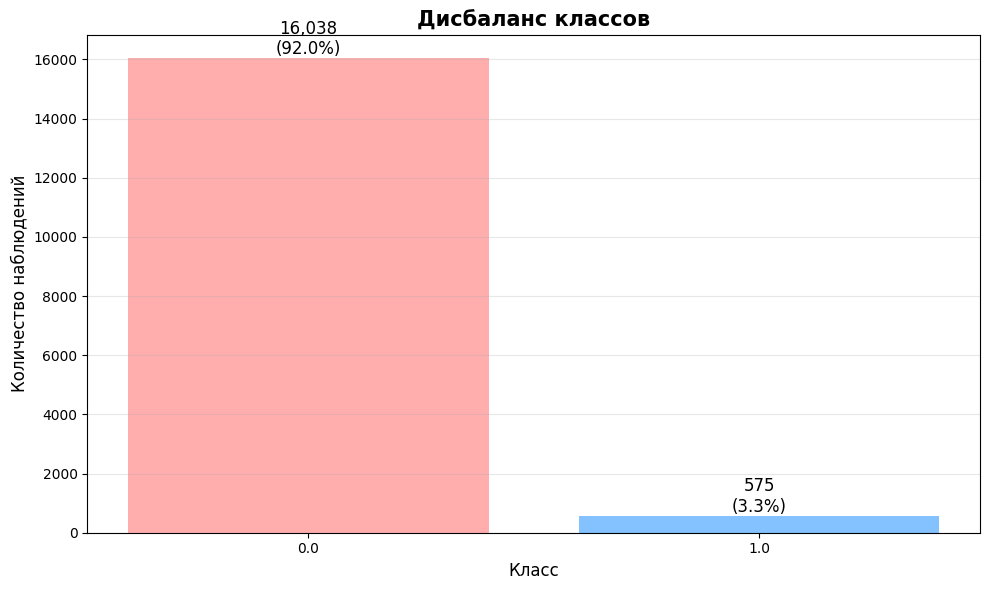

### 📈 Степень дисбаланса: 27.9:1

⚠️ **Сильный дисбаланс!** Требуются специальные методы обработки.

In [8]:
# Анализ дисбаланса классов
class_counts = df[target_variable].value_counts()
class_percentages = (class_counts / len(df)) * 100

display(Markdown("## ⚖️ Анализ дисбаланса классов"))
display(Markdown(f"### Целевая переменная: `{target_variable}`"))

# Создаем DataFrame для красивого отображения
balance_df = pd.DataFrame({
    'Класс': class_counts.index,
    'Количество': class_counts.values,
    'Процент': class_percentages.values
})
display(balance_df.style.background_gradient(cmap='Reds'))

# Визуализация дисбаланса
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(class_counts.index.astype(str), class_counts.values, 
              color=['#ff9999', '#66b3ff'], alpha=0.8)

# Добавляем значения над столбцами
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{height:,}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12)

ax.set_title('Дисбаланс классов', fontsize=15, fontweight='bold')
ax.set_xlabel('Класс', fontsize=12)
ax.set_ylabel('Количество наблюдений', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

imbalance_ratio = max(class_counts.values) / min(class_counts.values)
display(Markdown(f"### 📈 Степень дисбаланса: {imbalance_ratio:.1f}:1"))
if imbalance_ratio > 5:
    display(Markdown(f"⚠️ **Сильный дисбаланс!** Требуются специальные методы обработки."))
elif imbalance_ratio > 2:
    display(Markdown(f"🟡 **Умеренный дисбаланс.** Нужно учитывать при выборе метрик."))


In [10]:
display(Markdown("## 🕳️ Анализ пропущенных значений"))

## 🕳️ Анализ пропущенных значений

### 📊 Общая статистика по пропускам:

- Всего столбцов с пропусками: 419 из 419

- Средний процент пропусков: 61.59%

- Максимальный процент пропусков: 99.99%

### 🏆 Топ-20 столбцов с наибольшими пропусками:

,Столбец,Процент пропусков
25,Пробежки ЖТ,99.994263
26,Рецидивирующая ЖТ,99.994263
416,BNP (b),99.959839
24,ФЖ,99.959839
248,Максимальный прокальцитонин за сутки до развития SOFA 8,99.942628
316,Max Мезатона,99.942628
190,eGFR (a),99.936890
14,ОНМК (гем) в анамнезе,99.919679
43,EDV,99.908204
267,Количество часов применения антибиотика ДО развития SOFA 8 и более,99.885255


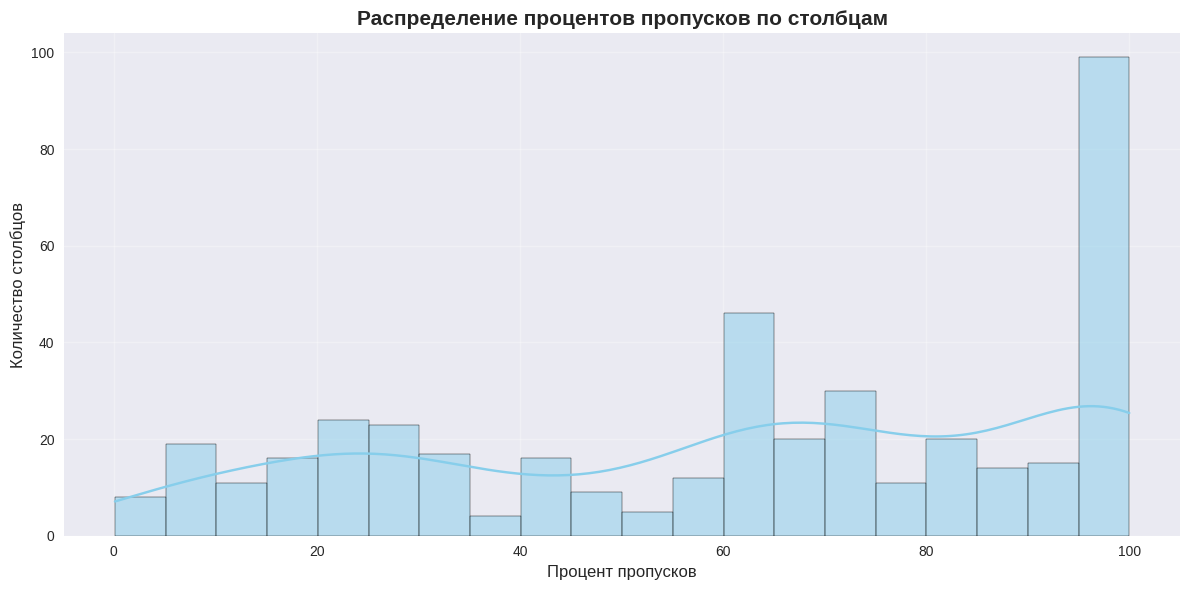

### 🎯 Анализ пропусков в контексте целевой переменной

#### Столбец: `Пробежки ЖТ`

**Абсолютные значения:**

Пробежки ЖТ,Значение,Пропуск,Всего
Смерть,,,
0.0,0,16038,16038
1.0,1,574,575
Всего,1,16612,16613


**Проценты:**

...

#### Столбец: `Максимальный прокальцитонин за сутки до развития SOFA 8`

**Абсолютные значения:**

Максимальный прокальцитонин за сутки до развития SOFA 8,Значение,Пропуск,Всего
Смерть,,,
0.0,8,16030,16038
1.0,2,573,575
Всего,10,16603,16613


**Проценты:**

Максимальный прокальцитонин за сутки до развития SOFA 8,Значение,Пропуск,Всего
Смерть,,,
0.000000,80.0%,96.5%,96.5%
1.000000,20.0%,3.5%,3.5%
Всего,100.0%,100.0%,100.0%


In [8]:
# Расчет процента пропусков для каждого столбца
missing_percentages = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Столбец': missing_percentages.index,
    'Процент пропусков': missing_percentages.values
}).sort_values('Процент пропусков', ascending=False)

# Фильтруем столбцы с пропусками > 0%
missing_df = missing_df[missing_df['Процент пропусков'] > 0]

display(Markdown(f"### 📊 Общая статистика по пропускам:"))
display(Markdown(f"- Всего столбцов с пропусками: {len(missing_df)} из {len(df.columns)}"))
display(Markdown(f"- Средний процент пропусков: {missing_df['Процент пропусков'].mean():.2f}%"))
display(Markdown(f"- Максимальный процент пропусков: {missing_df['Процент пропусков'].max():.2f}%"))

# Показываем топ-20 столбцов с наибольшими пропусками
display(Markdown("### 🏆 Топ-20 столбцов с наибольшими пропусками:"))
display(missing_df.head(20).style.background_gradient(cmap='YlOrRd', subset=['Процент пропусков']))

# Визуализация распределения пропусков
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(missing_df['Процент пропусков'], bins=20, kde=True, color='skyblue', ax=ax)
ax.set_title('Распределение процентов пропусков по столбцам', fontsize=15, fontweight='bold')
ax.set_xlabel('Процент пропусков', fontsize=12)
ax.set_ylabel('Количество столбцов', fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Анализ пропусков по классам целевой переменной (если target известен)
if target_variable in df.columns:
    display(Markdown("### 🎯 Анализ пропусков в контексте целевой переменной"))
    
    # Выбираем несколько ключевых столбцов с пропусками для анализа
    key_missing_cols = missing_df.head(5)['Столбец'].tolist()
    
    for col in key_missing_cols:
        if col != target_variable:
            display(Markdown(f"#### Столбец: `{col}`"))
            
            # Создаем таблицу пропусков vs target
            missing_analysis = pd.crosstab(
                df[target_variable],
                df[col].isnull().map({True: 'Пропуск', False: 'Значение'}),
                margins=True,
                margins_name='Всего'
            )
            
            # Добавляем проценты
            missing_analysis_pct = missing_analysis.copy()
            for col_name in missing_analysis_pct.columns:
                missing_analysis_pct[col_name] = (missing_analysis_pct[col_name] / 
                                                missing_analysis_pct[col_name]['Всего'] * 100)
            
            display(Markdown("**Абсолютные значения:**"))
            display(missing_analysis)
            display(Markdown("**Проценты:**"))
            display(missing_analysis_pct.style.format("{:.1f}%"))

In [9]:
numeric_cols = df.select_dtypes(include=['float64']).columns
print(f"Собрано {len(numeric_cols)} цифровых колонок")

Собрано 299 цифровых колонок


In [10]:
target_variable = 'Смерть'

In [11]:
display(Markdown("## 🔍 Поиск утечек данных (data leaks)"))

# 1. Поиск признаков с очень высокой корреляцией с target
display(Markdown("### 📈 Поиск признаков с крайне высокой корреляцией с target"))

# Подготавливаем данные для корреляционного анализа
# Создаем копию для анализа, удаляя полностью пустые столбцы
df_analysis = df.copy()

# Удаляем столбцы с 100% пропусков
cols_to_drop = df_analysis.columns[df_analysis.isnull().mean() == 1.0]
if len(cols_to_drop) > 0:
    display(Markdown(f"Удаляем {len(cols_to_drop)} столбцов с 100% пропусков"))
    df_analysis = df_analysis.drop(columns=cols_to_drop)

# Фильтруем только числовые признаки для корреляционного анализа
numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()

# Удаляем target из списка числовых признаков для анализа
if target_variable in numeric_cols:
    numeric_cols.remove(target_variable)

display(Markdown(f"### Числовые признаки для анализа: {len(numeric_cols)} из {len(df_analysis.columns)}"))

# Вычисляем корреляции только для числовых признаков
if target_variable in df_analysis.columns and len(numeric_cols) > 0:
    # Преобразуем target в числовой формат для корреляции, если это категориальный признак
    if not pd.api.types.is_numeric_dtype(df_analysis[target_variable]):
        # Создаем временную числовую версию target
        target_numeric = df_analysis[target_variable].astype('category').cat.codes
    else:
        target_numeric = df_analysis[target_variable]
    
    # Вычисляем корреляции
    correlations = {}
    for col in numeric_cols:
        # Удаляем строки с пропусками для этой пары признаков
        temp_df = df_analysis[[col, target_variable]].dropna()
        
        if len(temp_df) > 10:  # минимальное количество наблюдений для корреляции
            try:
                corr = temp_df[col].corr(temp_df[target_variable])
                if not np.isnan(corr):
                    correlations[col] = corr
            except:
                continue
    if correlations:
        # Создаем DataFrame с корреляциями
        corr_df = pd.DataFrame({
            'Признак': list(correlations.keys()),
            'Корреляция с target': list(correlations.values())
        }).sort_values('Корреляция с target', key=abs, ascending=False)
        
        # Выделяем признаки с очень высокой корреляцией (потенциальные утечки)
        high_corr_threshold = 0.85
        potential_leaks = corr_df[abs(corr_df['Корреляция с target']) >= high_corr_threshold]
        
        display(Markdown("### 📊 Топ-20 признаков по корреляции с target:"))
        display(corr_df.head(20).style.background_gradient(cmap='coolwarm', subset=['Корреляция с target'], vmin=-1, vmax=1))
        
        if not potential_leaks.empty:
            display(Markdown(f"### ⚠️ **ПОТЕНЦИАЛЬНЫЕ УТЕЧКИ ДАННЫХ** (|корреляция| >= {high_corr_threshold}):"))
            display(potential_leaks.style.background_gradient(cmap='Reds', subset=['Корреляция с target']))
            
            # Визуализация топ корреляций
            plt.figure(figsize=(14, 8))
            top_corr = corr_df.head(25)
            bars = plt.barh(top_corr['Признак'], top_corr['Корреляция с target'], 
                           color=['#ff4444' if abs(x) >= high_corr_threshold else '#4488ff' for x in top_corr['Корреляция с target']])
            
            plt.axvline(x=high_corr_threshold, color='r', linestyle='--', alpha=0.7, label=f'Порог утечки ({high_corr_threshold})')
            plt.axvline(x=-high_corr_threshold, color='r', linestyle='--', alpha=0.7)
            
            plt.title(f'Топ-25 корреляций с целевой переменной "{target_variable}"', fontsize=15, fontweight='bold')
            plt.xlabel('Корреляция с target', fontsize=12)
            plt.ylabel('Признаки', fontsize=12)
            plt.grid(axis='x', alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            display(Markdown("✅ Не обнаружено признаков с экстремально высокой корреляцией (потенциальных утечек)"))
    else:
        display(Markdown("❌ Не удалось вычислить корреляции. Проверьте типы данных и наличие пропусков."))


## 🔍 Поиск утечек данных (data leaks)

### 📈 Поиск признаков с крайне высокой корреляцией с target

### Числовые признаки для анализа: 298 из 419

### 📊 Топ-20 признаков по корреляции с target:

,Признак,Корреляция с target
233,LACTartMax (a),0.535278
234,LACTartMax,0.534135
232,LACTartMax (b),0.523252
167,APACHE сутки ПОСЛЕ развития SOFA 8 и более,0.517235
166,APACHE сутки до развития SOFA 8 и более,0.503873
274,LactVenMax (b),0.447614
189,Max Добутамин,0.442411
275,LactVenMax (a),0.439804
230,LACTartMin (a),0.438250
276,LactVenMax,0.436703


✅ Не обнаружено признаков с экстремально высокой корреляцией (потенциальных утечек)

In [12]:
display(Markdown("## 🏷️ Анализ категориальных признаков на предмет утечек"))

# Находим категориальные признаки
categorical_cols = df_analysis.select_dtypes(include=['object', 'category']).columns.tolist()
if target_variable in categorical_cols:
    categorical_cols.remove(target_variable)

display(Markdown(f"### Категориальные признаки для анализа: {len(categorical_cols)}"))

# Анализ категориальных признаков на предмет идеального разделения классов
if target_variable in df_analysis.columns and len(categorical_cols) > 0 and df_analysis[target_variable].nunique() == 2:
    display(Markdown("### 🔍 Поиск категориальных признаков с идеальным разделением классов"))
    
    potential_cat_leaks = []
    target_classes = df_analysis[target_variable].unique()
    target_classes = target_classes[~pd.isna(target_classes)]
    
    if len(target_classes) == 2:
        for col in categorical_cols:
            if df_analysis[col].nunique() < 20:  # ограничиваем для управляемости
                # Создаем таблицу сопряженности
                cross_tab = pd.crosstab(df_analysis[col], df_analysis[target_variable])
                
                if cross_tab.shape[0] > 1 and cross_tab.shape[1] == 2:
                    # Проверяем, есть ли категории, которые встречаются только в одном классе
                    for category in cross_tab.index:
                        row = cross_tab.loc[category]
                        if (row.iloc[0] == 0 and row.iloc[1] > 0) or (row.iloc[0] > 0 and row.iloc[1] == 0):
                            if row.sum() > 10:  # минимальное количество наблюдений
                                leak_ratio = max(row) / row.sum()
                                if leak_ratio > 0.95:  # 95% и более наблюдений в одной категории
                                    potential_cat_leaks.append({
                                        'Признак': col,
                                        'Категория': str(category),
                                        'Распределение': row.values.tolist(),
                                        'Процент в одном классе': leak_ratio * 100
                                    })
    
    if potential_cat_leaks:
        leak_df = pd.DataFrame(potential_cat_leaks)
        display(Markdown(f"### ⚠️ **ПОТЕНЦИАЛЬНЫЕ УТЕЧКИ в категориальных признаках** (95%+ наблюдений в одном классе):"))
        display(leak_df.style.background_gradient(cmap='Reds', subset=['Процент в одном классе']))
    else:
        display(Markdown("✅ Не обнаружено категориальных признаков с идеальным разделением классов"))


## 🏷️ Анализ категориальных признаков на предмет утечек

### Категориальные признаки для анализа: 120

### 🔍 Поиск категориальных признаков с идеальным разделением классов

### ⚠️ **ПОТЕНЦИАЛЬНЫЕ УТЕЧКИ в категориальных признаках** (95%+ наблюдений в одном классе):

,Признак,Категория,Распределение,Процент в одном классе
0,ХСН стадия,I,"[696, 0]",100.000000
1,Сопутствующие2,Подагра,"[28, 0]",100.000000
2,А-В блокада (степень),1 и 2 степень,"[14, 0]",100.000000
3,А-В блокада (степень),1 степень,"[19, 0]",100.000000


## 📐 Анализ мультиколлинеарности признаков

⚠️ Слишком много числовых признаков (298) для полного анализа мультиколлинеарности

Будем анализировать только топ-50 признаков по корреляции с target

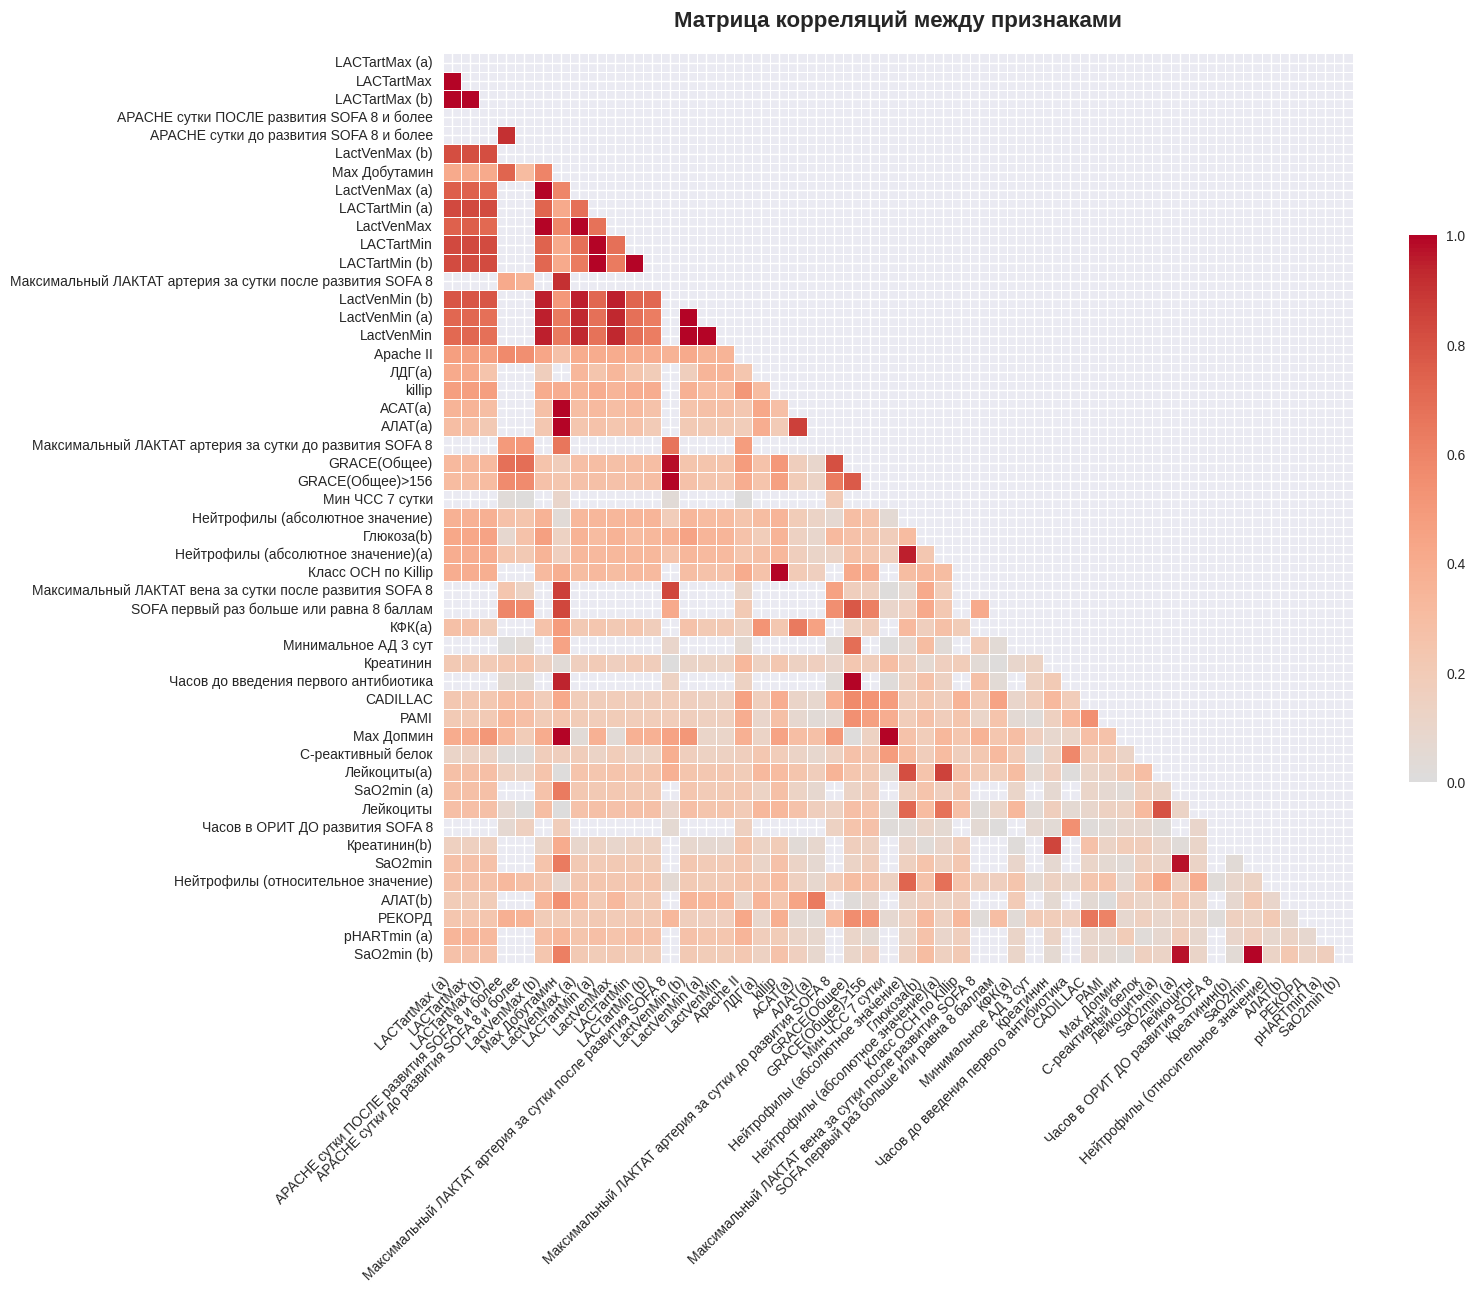

### ⚠️ Признаки с очень высокой корреляцией (> 0.95):

,Признак 1,Признак 2,Корреляция
2,LACTartMax (b),LACTartMax,1.000000
4,LactVenMax,LactVenMax (b),1.000000
8,LACTartMin (b),LACTartMin,1.000000
14,LactVenMin,LactVenMin (b),1.000000
27,SaO2min (b),SaO2min,1.000000
22,Часов до введения первого антибиотика,GRACE(Общее),1.000000
21,Класс ОСН по Killip,killip,1.000000
24,Max Допмин,Мин ЧСС 7 сутки,1.000000
23,Max Допмин,Max Добутамин,1.000000
19,GRACE(Общее)>156,Максимальный ЛАКТАТ артерия за сутки после развития SOFA 8,0.999788


In [13]:
display(Markdown("## 📐 Анализ мультиколлинеарности признаков"))

# Вычисляем мультиколлинеарность для числовых признаков
if len(numeric_cols) > 10:
    display(Markdown(f"⚠️ Слишком много числовых признаков ({len(numeric_cols)}) для полного анализа мультиколлинеарности"))
    display(Markdown("Будем анализировать только топ-50 признаков по корреляции с target"))
    
    # Берем топ-50 признаков по корреляции с target
    top_features = corr_df.head(50)['Признак'].tolist() if 'corr_df' in locals() else numeric_cols[:50]
else:
    top_features = numeric_cols

if len(top_features) > 1:
    # Создаем матрицу корреляций для топ признаков
    corr_matrix = df_analysis[top_features].corr().abs()
    
    # Визуализация тепловой карты
    plt.figure(figsize=(16, 14))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, 
                mask=mask,
                annot=False,
                cmap='coolwarm',
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": .5},
                vmin=0,
                vmax=1)
    
    plt.title('Матрица корреляций между признаками', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    # Находим пары признаков с очень высокой корреляцией
    high_corr_pairs = []
    threshold = 0.95
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i, j] > threshold:
                high_corr_pairs.append({
                    'Признак 1': corr_matrix.columns[i],
                    'Признак 2': corr_matrix.columns[j],
                    'Корреляция': corr_matrix.iloc[i, j]
                })
    
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Корреляция', ascending=False)
        display(Markdown(f"### ⚠️ Признаки с очень высокой корреляцией (> {threshold}):"))
        display(high_corr_df.style.background_gradient(cmap='Oranges', subset=['Корреляция']))
    else:
        display(Markdown("✅ Не обнаружено признаков с экстремально высокой корреляцией между собой"))


## 📈 Анализ распределений признаков по классам target

### Распределения топ-10 признаков по классам target:

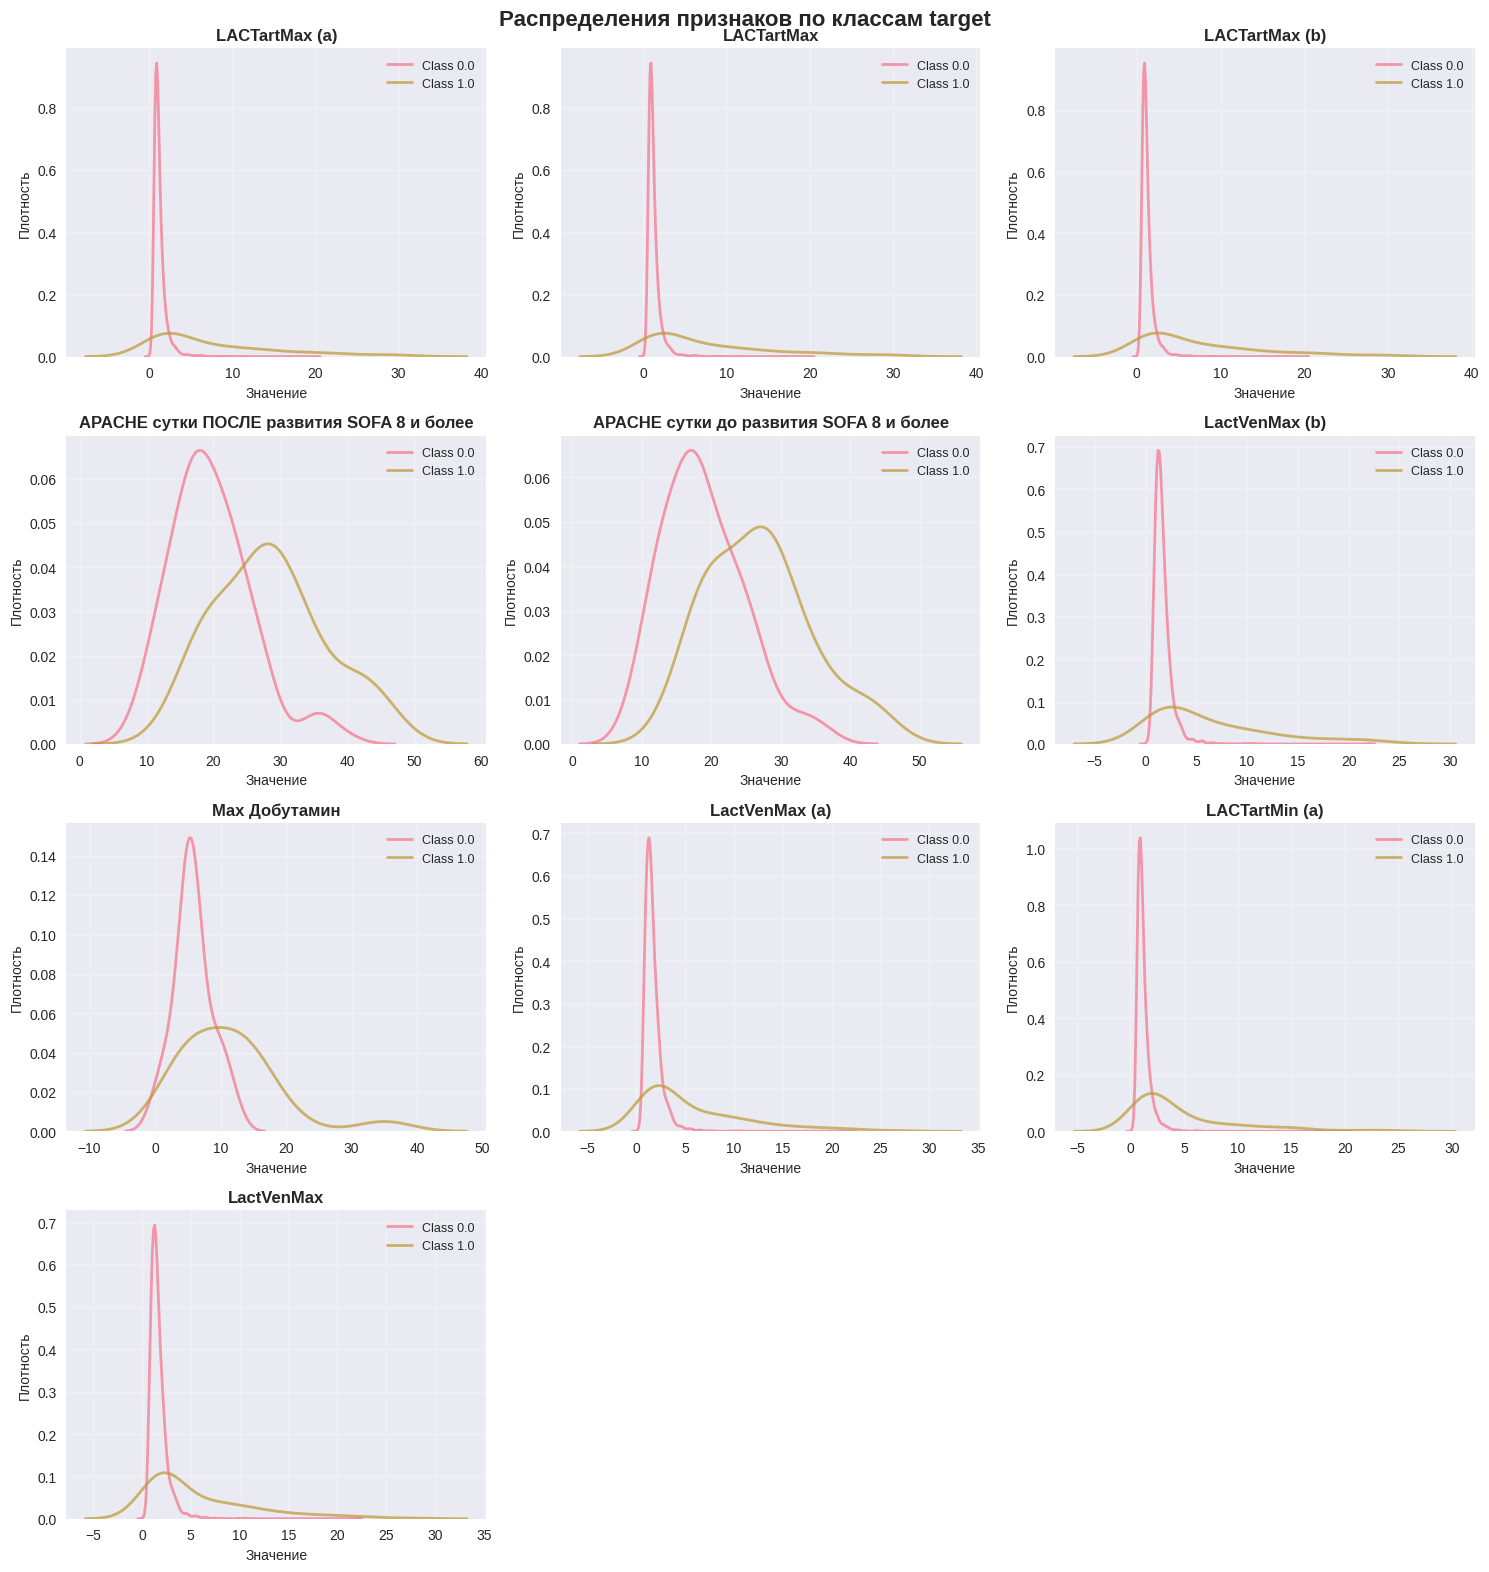

In [14]:
display(Markdown("## 📈 Анализ распределений признаков по классам target"))

# Анализируем распределения для топ признаков по корреляции
if target_variable in df_analysis.columns and len(numeric_cols) > 0:
    # Берем топ-10 признаков по корреляции с target
    top_analysis_features = corr_df.head(10)['Признак'].tolist() if 'corr_df' in locals() else numeric_cols[:10]
    
    # Удаляем признаки, которые являются потенциальными утечками
    if 'potential_leaks' in locals() and not potential_leaks.empty:
        leak_features = potential_leaks['Признак'].tolist()
        top_analysis_features = [f for f in top_analysis_features if f not in leak_features]
    
    if top_analysis_features:
        display(Markdown(f"### Распределения топ-{len(top_analysis_features)} признаков по классам target:"))
        
        # Создаем фигуру с подграфиками
        n_features = len(top_analysis_features)
        n_cols = 3
        n_rows = (n_features + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), 
                                squeeze=False, tight_layout=True)
        
        # Извлекаем классы target
        target_classes = df_analysis[target_variable].unique()
        target_classes = target_classes[~pd.isna(target_classes)]
        
        for i, feature in enumerate(top_analysis_features):
            row = i // n_cols
            col = i % n_cols
            ax = axes[row, col]
            
            # Строим распределения для каждого класса
            for class_val in target_classes:
                class_data = df_analysis[df_analysis[target_variable] == class_val][feature]
                class_data = class_data.replace([np.inf, -np.inf], np.nan).dropna()
                
                if len(class_data) > 10:
                    sns.kdeplot(class_data, ax=ax, label=f'Class {class_val}', 
                               alpha=0.7, linewidth=2)
            
            ax.set_title(f'{feature}', fontsize=12, fontweight='bold')
            ax.set_xlabel('Значение', fontsize=10)
            ax.set_ylabel('Плотность', fontsize=10)
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)
        # Скрываем пустые subplot
        for i in range(len(top_analysis_features), n_rows * n_cols):
            row = i // n_cols
            col = i % n_cols
            axes[row, col].set_visible(False)
        
        plt.suptitle('Распределения признаков по классам target', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, precision_recall_curve, auc
import re
from collections import Counter

In [16]:
display(Markdown("## 🎯 Цели предобработки:"))
display(Markdown("""
1. **Сократить 465 признаков** до 20-50 наиболее значимых
2. **Обработать пропуски** без импутации (только удаление и индикаторы)
3. **Подготовить данные** для работы с дисбалансом 97%/3%
4. **Удалить вредные признаки** (только в одном классе, пустые, избыточные)
5. **Сохранить медицинский смысл** оставшихся признаков
"""))

## 🎯 Цели предобработки:


1. **Сократить 465 признаков** до 20-50 наиболее значимых
2. **Обработать пропуски** без импутации (только удаление и индикаторы)
3. **Подготовить данные** для работы с дисбалансом 97%/3%
4. **Удалить вредные признаки** (только в одном классе, пустые, избыточные)
5. **Сохранить медицинский смысл** оставшихся признаков


In [17]:
# Проверяем, что у нас есть df из предыдущих шагов
if 'df' not in globals():
    display(Markdown("❌ **Данные не загружены!** Выполните сначала ячейки с EDA и загрузкой данных."))
else:
    display(Markdown("✅ **Данные доступны из предыдущих шагов**"))
    display(Markdown(f"Текущий размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов"))


✅ **Данные доступны из предыдущих шагов**

Текущий размер данных: 17430 строк, 419 столбцов

In [18]:
TARGET_VARIABLE = target_variable

In [10]:
df_prep = df.copy()

In [11]:
initial_count = len(df_prep)
df_prep = df_prep.dropna(subset=[target_variable])
removed_target_missing = initial_count - len(df_prep)

if removed_target_missing > 0:
    display(Markdown(f"### 🗑️ Удалено {removed_target_missing} строк с пропусками в целевой переменной"))

### 🗑️ Удалено 817 строк с пропусками в целевой переменной

In [12]:
y = df_prep[target_variable].astype(int)
class_counts = y.value_counts()
    
display(Markdown("## ⚖️ Финальный дисбаланс классов:"))
balance_df = pd.DataFrame({
    'Класс': class_counts.index,
    'Количество': class_counts.values,
    'Процент': (class_counts / len(y) * 100).values
})
display(balance_df.style.background_gradient(cmap='Reds'))

if len(class_counts) < 2:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ОШИБКА: Остался только один класс!**"))
elif min(class_counts) < 10:
    display(Markdown(f"⚠️ **ОПАСНЫЙ ДИСБАЛАНС: В minority классе всего {min(class_counts)} наблюдений!**"))


## ⚖️ Финальный дисбаланс классов:

,Класс,Количество,Процент
0,0,16038,96.538855
1,1,575,3.461145


In [21]:
display(Markdown("## 🕳️ Шаг 2: Стратегическая обработка пропусков"))

## 🕳️ Шаг 2: Стратегическая обработка пропусков

In [13]:
X = df_prep.drop(columns=[target_variable])

# 2.1 Удаление признаков с экстремальным количеством пропусков (>70%)
missing_percentages = (X.isnull().sum() / len(X)) * 100
high_missing_threshold = 70  # 70% пропусков как порог для удаления
cols_to_drop_high_missing = missing_percentages[missing_percentages > high_missing_threshold].index.tolist()

if cols_to_drop_high_missing:
    display(Markdown(f"### 🗑️ Удаляем {len(cols_to_drop_high_missing)} признаков с >{high_missing_threshold}% пропусков:"))
    display(Markdown(f"{cols_to_drop_high_missing[:10]}{'...' if len(cols_to_drop_high_missing) > 10 else ''}"))
    X = X.drop(columns=cols_to_drop_high_missing)
else:
    display(Markdown("✅ Нет признаков для удаления по критерию >70% пропусков"))

### 🗑️ Удаляем 177 признаков с >70% пропусков:

['ОНМК (гем) в анамнезе', 'Стентирование в анамнезе', 'Форма ФП', 'Калий', 'Дилатация предсердий', 'ФП при окс (до чкв)', 'ФП постоянная форма', 'ФЖ', 'Пробежки ЖТ', 'Рецидивирующая ЖТ']...

In [14]:
X_raw = X.copy()  # Сохраняем исходные данные перед обработкой
y_raw = y.copy()

In [15]:
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

In [16]:
display(Markdown(f"### 📊 Распределение типов признаков:"))
display(Markdown(f"- **Числовых признаков:** {len(numeric_cols)}"))
display(Markdown(f"- **Категориальных признаков:** {len(categorical_cols)}"))
display(Markdown(f"- **Всего признаков:** {len(X_raw.columns)}"))

### 📊 Распределение типов признаков:

- **Числовых признаков:** 177

- **Категориальных признаков:** 64

- **Всего признаков:** 241

In [17]:
# Показываем примеры категориальных признаков
if categorical_cols:
    display(Markdown("### 🔍 Примеры категориальных признаков:"))
    for col in categorical_cols[:5]:
        unique_vals = X_raw[col].dropna().unique()[:5]
        display(Markdown(f"- `{col}`: примеры значений {unique_vals}{'...' if len(unique_vals) > 5 else ''}"))
else:
    display(Markdown("✅ Нет категориальных признаков для обработки"))

### 🔍 Примеры категориальных признаков:

- `Sex`: примеры значений ['М' 'Ж']

- `STEMI`: примеры значений ['Нет' 'Да']

- `ЧКВ`: примеры значений ['Да' 'Нет']

- `Вид STEMI`: примеры значений ['Передний' 'Задний']

- `Инфаркт-зависимая артерия`: примеры значений [2 'ПМЖВ - Несовадает' 'ПКА - Несовадает' 'ПМЖВ' 'ОВ - Несовадает']

In [67]:
display(Markdown("### 🔄 Кодирование категориальных признаков"))

### 🔄 Кодирование категориальных признаков

In [18]:
X_encoded = X_raw.copy()

In [19]:
for col in categorical_cols:
    # Считаем количество уникальных значений
    n_unique = X_encoded[col].nunique()
    n_samples = len(X_encoded)
    
    # Выбираем стратегию кодирования
    if n_unique == 2:
        # Бинарное кодирование для бинарных признаков
        unique_vals = X_encoded[col].dropna().unique()
        mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
        X_encoded[col] = X_encoded[col].map(mapping)
        display(Markdown(f"✅ Бинарное кодирование: `{col}` → 0/1"))
        
    elif n_unique <= 10:
        # One-hot encoding для признаков с малым количеством категорий
        dummies = pd.get_dummies(X_encoded[col], prefix=col, drop_first=True)
        X_encoded = pd.concat([X_encoded, dummies], axis=1)
        X_encoded = X_encoded.drop(columns=[col])
        display(Markdown(f"✅ One-hot encoding: `{col}` → {len(dummies.columns)} новых признаков"))
        
    else:
        # Frequency encoding для признаков с большим количеством категорий
        freq_map = X_encoded[col].value_counts(normalize=True)
        X_encoded[f"{col}_freq"] = X_encoded[col].map(freq_map)
        X_encoded = X_encoded.drop(columns=[col])
        display(Markdown(f"✅ Frequency encoding: `{col}` → частотное представление"))

display(Markdown(f"### 📈 Размер после кодирования: {X_encoded.shape[0]} строк, {X_encoded.shape[1]} столбцов"))

✅ Бинарное кодирование: `Sex` → 0/1

✅ Бинарное кодирование: `STEMI` → 0/1

✅ Бинарное кодирование: `ЧКВ` → 0/1

✅ Бинарное кодирование: `Вид STEMI` → 0/1

✅ Frequency encoding: `Инфаркт-зависимая артерия` → частотное представление

...

✅ Бинарное кодирование: `Норадреналин` → 0/1

✅ Бинарное кодирование: `Левосимендан` → 0/1

✅ Бинарное кодирование: `Мезатон` → 0/1

✅ Бинарное кодирование: `UA (нестабильная стенокардия)` → 0/1

### 📈 Размер после кодирования: 16613 строк, 259 столбцов

In [20]:
X = X_encoded.copy()

In [21]:
# 2.2 Удаление пустых и константных признаков
empty_cols = X.columns[X.isnull().all()].tolist()
if empty_cols:
    display(Markdown(f"Удаляем пустые признаки: {empty_cols}"))
    X = X.drop(columns=empty_cols)

constant_cols = X.columns[X.nunique() == 1].tolist()
if constant_cols:
    display(Markdown(f"Удаляем константные признаки: {constant_cols[:5]}{'...' if len(constant_cols) > 5 else ''}"))
    X = X.drop(columns=constant_cols)

In [26]:
display(Markdown("### 🔍 Поиск признаков, присутствующих только в одном классе"))

### 🔍 Поиск признаков, присутствующих только в одном классе

In [31]:
# Работаем только с числовыми признаками для этой проверки
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
one_class_features = []

for col in numeric_cols:
    # Проверяем наличие значений в каждом классе
    class_0_data = X[y == 0][col]
    class_1_data = X[y == 1][col]
    
    count_0 = class_0_data.count()
    count_1 = class_1_data.count()
    
    # Если признак есть только в одном классе и имеет достаточно наблюдений
    if (count_0 == 0 and count_1 >= 5) or (count_1 == 0 and count_0 >= 5):
        one_class_features.append({
            'feature': col,
            'class_0_count': count_0,
            'class_1_count': count_1,
            'only_in_class': 1 if count_0 == 0 else 0
        })

In [32]:
if one_class_features:
    one_class_df = pd.DataFrame(one_class_features)
    display(Markdown(f"### ⚠️ Найдено {len(one_class_features)} признаков, присутствующих только в одном классе:"))
    display(one_class_df.style.background_gradient(cmap='Reds'))
    
    # Удаляем такие признаки
    features_to_drop = one_class_df['feature'].tolist()
    display(Markdown(f"**Удаляем {len(features_to_drop)} признаков как потенциальные скрытые утечки**"))
    X = X.drop(columns=features_to_drop)
else:
    display(Markdown("✅ Не обнаружено признаков, присутствующих только в одном классе"))

✅ Не обнаружено признаков, присутствующих только в одном классе

In [29]:
display(Markdown("### 🚩 Создание индикаторов пропусков"))

### 🚩 Создание индикаторов пропусков

In [31]:
# Сначала определим важные признаки через корреляцию (только числовые)
important_features = []
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

if numeric_cols:
    correlations = {}
    for col in numeric_cols:
        temp_df = pd.concat([X[col], y], axis=1).dropna()
        if len(temp_df) > 10:  # минимальное количество наблюдений
            try:
                # ГАРАНТИРУЕМ ЧИСЛОВОЙ ФОРМАТ ДЛЯ КОРРЕЛЯЦИИ
                col_values = pd.to_numeric(temp_df[col], errors='coerce')
                target_values = pd.to_numeric(temp_df.iloc[:, 1], errors='coerce')
                
                valid_data = pd.concat([col_values, target_values], axis=1).dropna()
                
                if len(valid_data) > 10 and valid_data.iloc[:, 0].nunique() > 1:
                    corr = valid_data.iloc[:, 0].corr(valid_data.iloc[:, 1])
                    if not np.isnan(corr):
                        correlations[col] = abs(corr)
            except Exception as e:
                continue  # Пропускаем проблемные признаки
    
    if correlations:
        # Берем топ-20 признаков по корреляции
        important_features = sorted(correlations.items(), key=lambda x: x[1], reverse=True)[:20]
        important_features = [feat for feat, _ in important_features]
        display(Markdown(f"### Важные признаки для индикаторов пропусков: {len(important_features)} - {important_features}"))
    else:
        # Если корреляция не работает, берем первые 20 числовых признаков
        important_features = numeric_cols[:20]
        display(Markdown("ℹ️ Не удалось вычислить корреляции - используем первые 20 числовых признаков"))


### Важные признаки для индикаторов пропусков: 20 - ['LACTartMax (a)', 'LACTartMax', 'LACTartMax (b)', 'LactVenMax (a)', 'LACTartMin (a)', 'LactVenMax', 'LACTartMin', 'LACTartMin (b)', 'LactVenMin (a)', 'LactVenMin', 'Apache II', 'killip', 'АСАТ(a)', 'АЛАТ(a)', 'GRACE(Общее)', 'GRACE(Общее)>156', 'Нейтрофилы (абсолютное значение)', 'Нейтрофилы (абсолютное значение)(a)', 'Класс ОСН по Killip', 'КФК(a)']

In [32]:
# Создаем индикаторы пропусков
missing_indicators_created = 0
for feature in important_features:
    if feature in X.columns:
        missing_count = X[feature].isnull().sum()
        if 0 < missing_count < len(X):  # есть и пропуски, и значения
            missing_col_name = f"{feature}_missing"
            if missing_col_name not in X.columns:
                X[missing_col_name] = X[feature].isnull().astype(int)
                missing_indicators_created += 1

if missing_indicators_created > 0:
    display(Markdown(f"### ✅ Создано {missing_indicators_created} индикаторов пропусков"))
else:
    display(Markdown("✅ Индикаторы пропусков не требуются (нет пропусков в важных признаках)"))

### ✅ Создано 20 индикаторов пропусков

In [33]:
display(Markdown("## 🔍 Шаг 3: Отбор признаков"))

## 🔍 Шаг 3: Отбор признаков

In [34]:
display(Markdown("### 📐 Устранение мультиколлинеарности"))

### 📐 Устранение мультиколлинеарности

In [22]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
features_to_remove_corr = []

In [23]:
if len(numeric_cols) > 5:
    # Создаем копию для анализа корреляций
    X_corr = X[numeric_cols].copy()
    
    # Удаляем пропуски ТОЛЬКО ДЛЯ АНАЛИЗА КОРРЕЛЯЦИЙ
    # X_corr_clean = X_corr.dropna()
    X_corr_clean = X_corr
    
    if len(X_corr_clean) > 10:
        corr_matrix = X_corr_clean.corr().abs()
        
        # Находим пары признаков с корреляцией > 0.85
        high_corr_threshold = 0.85
        high_corr_pairs = []
        
        for i in range(len(corr_matrix.columns)):
            for j in range(i):
                if corr_matrix.iloc[i, j] > high_corr_threshold:
                    high_corr_pairs.append({
                        'feature1': corr_matrix.columns[i],
                        'feature2': corr_matrix.columns[j],
                        'correlation': corr_matrix.iloc[i, j]
                    })
        
        if high_corr_pairs:
            high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
            display(Markdown(f"### Найдено {len(high_corr_pairs)} пар признаков с корреляцией > {high_corr_threshold}:"))
            
            # Удаляем один из пары - тот, у которого меньше корреляция с target
            for _, row in high_corr_df.iterrows():
                if row['feature1'] in X.columns and row['feature2'] in X.columns:
                    # Вычисляем корреляцию с target (гарантируем числовой формат)
                    temp_df1 = pd.concat([X[row['feature1']], y], axis=1).dropna()
                    temp_df2 = pd.concat([X[row['feature2']], y], axis=1).dropna()

                    if len(temp_df1) > 10 and len(temp_df2) > 10:
                        try:
                            # Приводим к числовому формату
                            feat1_num = pd.to_numeric(temp_df1.iloc[:, 0], errors='coerce')
                            feat2_num = pd.to_numeric(temp_df2.iloc[:, 0], errors='coerce')
                            target_num = pd.to_numeric(temp_df1.iloc[:, 1], errors='coerce')
                            
                            valid1 = pd.concat([feat1_num, target_num], axis=1).dropna()
                            valid2 = pd.concat([feat2_num, target_num], axis=1).dropna()
                            
                            if len(valid1) > 10 and len(valid2) > 10:
                                corr1 = valid1.iloc[:, 0].corr(valid1.iloc[:, 1])
                                corr2 = valid2.iloc[:, 0].corr(valid2.iloc[:, 1])
                                
                                # Выбираем признак с меньшей корреляцией к target для удаления
                                feature_to_remove = row['feature1'] if abs(corr1) < abs(corr2) else row['feature2']
                                if feature_to_remove not in features_to_remove_corr:
                                    features_to_remove_corr.append(feature_to_remove)
                        except:
                            continue
        
        if features_to_remove_corr:
            display(Markdown(f"### 🗑️ Удаляем {len(features_to_remove_corr)} мультиколлинеарных признаков:"))
            display(Markdown(f"{features_to_remove_corr[:10]}{'...' if len(features_to_remove_corr) > 10 else ''}"))
            X = X.drop(columns=features_to_remove_corr)
        else:
            display(Markdown("✅ Не обнаружено сильно коррелирующих признаков для удаления"))
    else:
        display(Markdown("ℹ️ Недостаточно данных для анализа мультиколлинеарности"))
else:
    display(Markdown("ℹ️ Недостаточно числовых признаков для анализа мультиколлинеарности"))

### Найдено 176 пар признаков с корреляцией > 0.85:

### 🗑️ Удаляем 69 мультиколлинеарных признаков:

['Класс ОСН по Killip', 'pHARTmax', 'pO2ARTmin (b)', 'pO2ARTmax (b)', 'pCO2min (b)', 'pHARTmin (b)', 'pCO2max', 'HCO3ArtMax (b)', 'BEArtMax (b)', 'HCO3ArtMin (b)']...

In [40]:
display(Markdown("### 🎯 Финальный отбор признаков"))

### 🎯 Финальный отбор признаков

In [35]:
final_features = X.columns.tolist()

In [36]:
# Если признаков слишком много (>50), оставляем только лучшие
if len(final_features) > 50:
    # Используем только числовые признаки для отбора
    numeric_final = X.select_dtypes(include=[np.number]).columns.tolist()
    
    if numeric_final:
        # Быстрая оценка важности через корреляцию с target
        feature_scores = {}
        for col in numeric_final:
            temp_df = pd.concat([X[col], y], axis=1).dropna()
            if len(temp_df) > 10:
                try:
                    col_num = pd.to_numeric(temp_df[col], errors='coerce')
                    target_num = pd.to_numeric(temp_df.iloc[:, 1], errors='coerce')
                    valid_data = pd.concat([col_num, target_num], axis=1).dropna()
                    
                    if len(valid_data) > 10 and valid_data.iloc[:, 0].nunique() > 1:
                        corr = valid_data.iloc[:, 0].corr(valid_data.iloc[:, 1])
                        if not np.isnan(corr):
                            feature_scores[col] = abs(corr)
                except:
                    continue
        
        if feature_scores:
            # Берем топ-50 признаков
            top_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)[:50]
            final_features = [feat for feat, _ in top_features]
            
            # Добавляем индикаторы пропусков
            missing_indicators = [col for col in X.columns if col.endswith('_missing')]
            final_features.extend([col for col in missing_indicators if col not in final_features])
            
            display(Markdown(f"### ✅ Отобрано {len(final_features)} наиболее значимых признаков"))
        else:
            # Если корреляция не работает, берем первые 50 признаков
            final_features = X.columns[:50].tolist()
            display(Markdown("ℹ️ Не удалось оценить важность признаков - используем первые 50 признаков"))
    else:
        final_features = X.columns[:50].tolist()

display(Markdown(f"### 📊 Финальные признаки для моделирования: {len(final_features)}"))
display(Markdown(f"{final_features[:20]}{'...' if len(final_features) > 20 else ''}"))

### ✅ Отобрано 50 наиболее значимых признаков

### 📊 Финальные признаки для моделирования: 50

['LACTartMax (a)', 'LactVenMax (a)', 'LACTartMin (a)', 'Apache II', 'killip', 'АСАТ(a)', 'Адреналин', 'Отек легких', 'Отек легких(a)', 'GRACE(Общее)', 'Норадреналин', 'GRACE(Общее)>156', 'Нейтрофилы (абсолютное значение)(a)', 'КФК(a)', 'Креатинин', 'CADILLAC', 'PAMI', 'SaO2min (a)', 'Лейкоциты', 'Креатинин(b)']...

In [27]:
df_new = X.copy()  # создаем копию, чтобы не изменять оригинальные данные
df_new['target'] = y

In [29]:
df_new.to_csv("prepared_data.csv")

In [46]:
display(Markdown("## 📊 Шаг 4: Стратифицированное разделение данных"))

## 📊 Шаг 4: Стратифицированное разделение данных

In [37]:
X_final = X[final_features].copy()
y_final = y.copy()

In [38]:
total_missing = X_final.isnull().sum().sum()

In [39]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
            X_final, y_final,
            test_size=0.2,
            stratify=y_final,
            random_state=42
        )

In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

In [41]:
X_train

,LACTartMax (a),LactVenMax (a),LACTartMin (a),Apache II,killip,АСАТ(a),Адреналин,Отек легких,Отек легких(a),GRACE(Общее),Норадреналин,GRACE(Общее)>156,Нейтрофилы (абсолютное значение)(a),КФК(a),Креатинин,CADILLAC,PAMI,SaO2min (a),Лейкоциты,Креатинин(b),Нейтрофилы (относительное значение),РЕКОРД,pHARTmin (a),интегрилин|эптифибатид|коромакс|агграстат,МНО(a),Диастолического АД(b),HCO3ArtMin (a),PAMI (Высокий риск),ФВ ЛЖ,Отек легких(b),Глюкоза в мг/дл,Лимфоциты (относительное значение),ЧСС (b),TIMI (Летальность) (Высокий риск),Мочевина(a),STEMI,ПТИ(a),СДЛА,НПВ диаметр,GRACE(Общее)>140,MKB_freq,Сумма всех лейкоцитов,Стенокардия (ИБ),Количество дней в реанимации,Добутамин,ЧСС(а),TIMI (Летальность),PHVenMin,pCO2min (a),Распределение эритроцитов по объему (RDW-CV)
12998,0.7,1.4,0.7,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,78.00,NaN,0.0,98.4,8.30,78.00,NaN,1.0,7.40,0.0,NaN,80.0,24.2,1.0,NaN,NaN,NaN,NaN,66.0,0.0,7.63,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,60.0,5.0,7.33,39.3,NaN
15288,0.5,0.7,0.5,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,83.60,NaN,8.0,98.6,5.50,83.60,NaN,4.0,7.35,0.0,NaN,80.0,20.9,0.0,NaN,NaN,NaN,NaN,70.0,0.0,6.86,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,6.0,7.35,38.1,NaN
5071,NaN,NaN,NaN,10.0,2.0,16.98,0.0,1.0,0.0,135.0,0.0,0.0,3.95,64.59,88.00,NaN,7.0,NaN,7.40,88.00,53.3,2.0,NaN,0.0,NaN,84.0,NaN,0.0,71.0,1.0,130.4648,32.9,62.0,0.0,5.20,0.0,NaN,28.0,1.5,0.0,0.002190,100.0,1.0,2.0,0.0,70.0,4.0,NaN,NaN,12.5
13167,0.7,1.2,0.7,NaN,1.0,26.40,NaN,1.0,NaN,NaN,NaN,NaN,8.21,177.10,68.00,8.0,4.0,99.5,6.60,68.00,84.6,3.0,7.22,0.0,0.97,100.0,13.8,1.0,35.0,NaN,142.7184,12.0,70.0,0.0,9.24,0.0,111.0,40.0,NaN,NaN,NaN,104.2,1.0,NaN,NaN,68.0,7.0,7.28,32.6,14.3
2830,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0,NaN,0.0,NaN,6.86,NaN,154.26,NaN,NaN,NaN,14.00,NaN,65.8,2.0,NaN,0.0,1.77,90.0,NaN,NaN,47.0,1.0,NaN,7.4,100.0,0.0,9.73,0.0,95.3,38.0,1.5,1.0,0.164842,NaN,0.0,3.0,0.0,NaN,3.0,NaN,NaN,14.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15957,0.7,NaN,0.7,NaN,NaN,25.10,NaN,1.0,NaN,NaN,NaN,NaN,NaN,54.30,93.27,2.0,0.0,98.9,8.30,93.27,NaN,1.0,7.21,0.0,NaN,80.0,15.8,1.0,60.0,NaN,102.7140,NaN,62.0,0.0,5.31,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.0,5.0,NaN,41.0,NaN
7875,0.7,NaN,0.7,9.0,1.0,NaN,0.0,1.0,0.0,169.0,0.0,1.0,5.27,NaN,86.47,7.0,12.0,99.2,13.60,NaN,60.4,4.0,7.41,0.0,NaN,90.0,21.1,0.0,40.0,1.0,88.2980,NaN,95.0,0.0,6.15,1.0,NaN,25.0,1.8,1.0,0.164842,74.0,0.0,NaN,0.0,NaN,7.0,NaN,31.6,13.7
17038,NaN,NaN,NaN,NaN,1.0,NaN,0.0,1.0,0.0,133.0,0.0,0.0,5.82,NaN,119.00,2.0,2.0,NaN,10.50,NaN,65.8,1.0,NaN,0.0,1.28,75.0,NaN,1.0,59.0,1.0,NaN,26.6,60.0,0.0,6.90,1.0,57.6,46.0,1.6,0.0,0.160638,NaN,0.0,3.0,0.0,NaN,4.0,NaN,NaN,12.3
2229,NaN,NaN,NaN,10.0,1.0,25.95,0.0,1.0,0.0,109.0,0.0,0.0,3.87,16.87,103.00,NaN,0.0,NaN,7.69,103.00,50.3,1.0,NaN,0.0,NaN,75.0,NaN,1.0,NaN,1.0,91.5416,38.5,62.0,0.0,4.62,0.0,77.7,NaN,NaN,0.0,0.200841,100.0,1.0,2.0,0.0,72.0,4.0,NaN,NaN,13.2


In [42]:
display(Markdown("### ✅ Успешное разделение данных!"))
display(Markdown(f"**Размеры наборов:**"))
display(Markdown(f"- Train: {len(X_train)} ({sum(y_train == 1)/len(y_train)*100:.1f}% класса 1)"))
display(Markdown(f"- Validation: {len(X_val)} ({sum(y_val == 1)/len(y_val)*100:.1f}% класса 1)"))
display(Markdown(f"- Test: {len(X_test)} ({sum(y_test == 1)/len(y_test)*100:.1f}% класса 1)"))

### ✅ Успешное разделение данных!

**Размеры наборов:**

- Train: 9967 (3.5% класса 1)

- Validation: 3323 (3.5% класса 1)

- Test: 3323 (3.5% класса 1)

In [43]:
strat_check = pd.DataFrame({
    'Набор': ['Train', 'Validation', 'Test'],
    'Процент класса 1': [
        sum(y_train == 1)/len(y_train)*100,
        sum(y_val == 1)/len(y_val)*100,
        sum(y_test == 1)/len(y_test)*100
    ]
})
display(Markdown("**Проверка стратификации (процент minority класса):**"))
display(strat_check.style.background_gradient(cmap='Greens'))

**Проверка стратификации (процент minority класса):**

,Набор,Процент класса 1
0,Train,3.461423
1,Validation,3.460728
2,Test,3.460728


------------------------------

In [44]:
# Базовая информация о данных
display(Markdown("## 📊 Базовая информация о датасете"))

# Информация о типах данных
display(Markdown("### 💾 Информация о типах данных"))
buffer = pd.io.common.StringIO()
X.info(buf=buffer)
info_str = buffer.getvalue()
display(Markdown(f"```\n{info_str}\n```"))

info_df = pd.DataFrame({
    'Column': X.columns,
    'Type': X.dtypes.astype(str),
    'First Value': X.iloc[0].values,
    'Last Value': X.iloc[-1].values,
    'Unique Values': X.nunique().values
})

# Красивое отображение в Jupyter
display(info_df.style
        .set_caption("DataFrame Schema Overview")
        .format(precision=2)
        .background_gradient(cmap='Blues', subset=['Unique Values']))

# Описательная статистика
display(Markdown("### 📈 Описательная статистика числовых признаков"))
display(X.describe().T.style.background_gradient(cmap='viridis'))

# Первые и последние строки
display(Markdown("### 👀 Первые 5 строк данных"))
display(X.head())

display(Markdown("### 👀 Последние 5 строк данных"))
display(X.tail())

# Уникальные значения для категориальных признаков (первые 10 столбцов)
display(Markdown("### 🔍 Анализ уникальных значений (первые 10 столбцов)"))
unique_counts = {}
for col in X.columns[:10]:
    unique_counts[col] = {
        'unique_count': X[col].nunique(),
        'unique_values': X[col].unique()[:10].tolist(),
        'dtype': str(X[col].dtype)
    }

unique_df = pd.DataFrame(unique_counts).T
display(unique_df)

## 📊 Базовая информация о датасете

### 💾 Информация о типах данных

```
<class 'pandas.core.frame.DataFrame'>
Index: 16613 entries, 0 to 17429
Columns: 190 entries, Age to РЕКОРД (Высокий риск)_Нет
dtypes: bool(29), float64(161)
memory usage: 21.0 MB

```

,Column,Type,First Value,Last Value,Unique Values
Age,Age,float64,78.00,53.00,78
Sex,Sex,float64,0.00,0.00,2
STEMI,STEMI,float64,0.00,1.00,2
ЧКВ,ЧКВ,float64,0.00,0.00,2
Вид STEMI,Вид STEMI,float64,nan,1.00,2
Поражение ствола,Поражение ствола,float64,0.00,1.00,2
Количество пораженных сосудов(Значимость),Количество пораженных сосудов(Значимость),float64,2.00,2.00,5
TIMI,TIMI,float64,nan,3.00,4
Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (<3),float64,0.00,0.00,2
Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда в анамнезе (>3),float64,0.00,1.00,2


### 📈 Описательная статистика числовых признаков

...

,Age,Sex,STEMI,ЧКВ,Вид STEMI,Поражение ствола,Количество пораженных сосудов(Значимость),TIMI,Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда со стентированием в анамнезе,ОНМК (иш) в анамнезе,Тромболизис,ФП a (в анамнезе),ГБ риск,Стенокардия (ИБ),СД,ХБП,ЯБ,МКБ,ФВ ЛЖ,МЖП,ЗСЛЖ,ПСПЖ,СДЛА,Размер правого желудочка,НПВ диаметр,La1,La2,Ra1,Ra2,Гематокрит,Эритроциты,Лейкоциты,Тромбоциты,Нейтрофилы (относительное значение),Лимфоциты (абсолютное значение),Лимфоциты (относительное значение),Моноциты (абсолютное значение),Моноциты (относительное значение),Эозинофилы (абсолютное значение),Эозинофилы (относительное значение),Базофилы (относительное значение),Сумма всех лейкоцитов,Средний объем эритроцита,Среднее содержание гемоглобина в эритроците,"Ср, концентрация гемоглобина в эритроците",Распределение эритроцитов по объему (RDW-CV),Распределение эритроцитов по объему (RDW-SD),Средний объем тромбоцита (MPV),Расчетная ширина распределения тромбоцитов,Тромбокрит,Коэффициент крупных тромбоцитов,СОЭ,PLR (тромбоциты/лимфоциты абс) (61-239),MLR (моноциты/лимфоциты),LMR (лимфоциты абс/моноциты абс),SII (тромбоциты*нейтрофилы абс / лимфоциты абс),ELR (эозинофилы абс/лимфоциты абс,ENR (эозин абс/нейтрофилы абс),BLR (базофилы абс/лимфоциты абс),PIV or AISI (NxMxPLT)/L,GLR (глюкоза мг/дл / лимф абс),RLR (RDW/ lymph abs),MPV/PC (MPV/ PLT),Глюкоза в мг/дл,Креатинин(b),Мочевина(b),Продолжительность операции,длительность нахождения в стационаре,повторные операции,Количество дней в реанимации,Apache II,GRACE(Общее),GRACE(Общее)>140,интегрилин|эптифибатид|коромакс|агграстат,Рост,Вес,Индекс массы тела,Экстракардиальная артериопатия,Срочность,Систолическое АД(b),Диастолического АД(b),ЧСС (b),САД(a),ЧСС(а),Нейтрофилы (абсолютное значение)(a),Лимфоциты (абсолютное значение)(a),Моноциты (абсолютное значение)(a),Эозинофилы (абсолютное значение)(a),Базофилы (абсолютное значение)(a),Эр(a),Hb(a),Гематокрит(a),Тромбоциты(a),Моноциты(%)(a),АСАТ(a),Билирубин общий(a),Холестерин общий(a),Триглицериды(a),Мочевина(a),КФК(a),ПТИ(a),МНО(a),ФБГ(a),ТВ(a),АПТВ(a),Креатинин,СКФ,Smoking,Протокол коронарографии,Аортальный стеноз (Градиент),Аортальный стеноз (Заключение),ХОБЛ (Новый столбец),Стенокардия в диагнозе при поступлении,ПИКС в диагнозе при поступлении,Ишемический инсульт (Выгрузка из ИБ - временный столбец),Геморрагический инсульт (Выгрузка из ИБ - временный столбец),Инсульт (Выгрузка из ИБ - временный столбец),SpO2,Курит,GRACE(Общее)>156,Отек легких(b),Отек легких(a),Отек легких,Медицинская помощь оказана за первые 4 часа,Гипертоническая болезнь,CADILLAC,РЕКОРД,PAMI,TIMI (Летальность),TIMI (Летальность) (Средний риск),TIMI (Летальность) (Высокий риск),PAMI (Низкий риск),PAMI (Средний риск),PAMI (Высокий риск),А-В блокаДа (Новый),Адреналин,Добутамин,Допмин,Норадреналин,Левосимендан,Мезатон,killip,pHARTmin (a),pO2ARTmax,pCO2min (a),SaO2min (a),SaO2max (a),LACTartMin (a),LACTartMax (a),HCO3ArtMin (a),PHVenMin,PO2VenMin,PCO2VenMax,ScvO2Min,LactVenMax (a),BEVenMin (a),Инфаркт-зависимая артерия_freq,ФП b (после чкв)_ЛОЖЬ,ФП b (после чкв)_Нет,MKB_freq,ХСН стадия_2b,ХСН стадия_I,ХСН стадия_II,ХСН стадия_IIA,ХСН стадия_IIB,Стенокардия форма(ИБ)_Нет,Стенокардия форма(ИБ)_Стабильная,Стеноз аортального клапана (степень)_1,Стеноз аортального клапана (степень)_Умеренный,Экстренная операция(ИБ)(Новый)_Нет,Экстренная операция(ИБ)(Новый)_Плановая,Экстренная операция(ИБ)(Новый)_Экстренная,Сопутствующие1_freq,CADILLAC (Низкий риск)_1,CADILLAC (Низкий риск)_Да,CADILLAC (Низкий риск)_Нет,CADILLAC (Средний риск)_1,CADILLAC (Средний риск)_Да,CADILLAC (Средний риск)_Нет,CADILLAC (Высокий риск)_1,CADILLAC (Высокий риск)_Да,CADILLAC (Высокий риск)_Нет,РЕКОРД (Низкий риск)_1,РЕКОРД (Низкий риск)_Да,РЕКОРД (Низкий риск)_Нет,РЕКОРД (Высокий риск)_1,РЕКОРД (Высокий риск)_Да,РЕКОРД (Высокий риск)_Нет
0,78.0,0.0,0.0,0.0,NaN,0.0,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,NaN,0.0,57.0,1.0,1.1,0.35,57.0,2.2,1.5,4.0,6.0,4.0,5.1,NaN,5.00,8.36,178.0,52.6,2.84,34.0,0.

### 👀 Последние 5 строк данных

,Age,Sex,STEMI,ЧКВ,Вид STEMI,Поражение ствола,Количество пораженных сосудов(Значимость),TIMI,Инфаркт миокарда в анамнезе (<3),Инфаркт миокарда в анамнезе (>3),Инфаркт миокарда со стентированием в анамнезе,ОНМК (иш) в анамнезе,Тромболизис,ФП a (в анамнезе),ГБ риск,Стенокардия (ИБ),СД,ХБП,ЯБ,МКБ,ФВ ЛЖ,МЖП,ЗСЛЖ,ПСПЖ,СДЛА,Размер правого желудочка,НПВ диаметр,La1,La2,Ra1,Ra2,Гематокрит,Эритроциты,Лейкоциты,Тромбоциты,Нейтрофилы (относительное значение),Лимфоциты (абсолютное значение),Лимфоциты (относительное значение),Моноциты (абсолютное значение),Моноциты (относительное значение),Эозинофилы (абсолютное значение),Эозинофилы (относительное значение),Базофилы (относительное значение),Сумма всех лейкоцитов,Средний объем эритроцита,Среднее содержание гемоглобина в эритроците,"Ср, концентрация гемоглобина в эритроците",Распределение эритроцитов по объему (RDW-CV),Распределение эритроцитов по объему (RDW-SD),Средний объем тромбоцита (MPV),Расчетная ширина распределения тромбоцитов,Тромбокрит,Коэффициент крупных тромбоцитов,СОЭ,PLR (тромбоциты/лимфоциты абс) (61-239),MLR (моноциты/лимфоциты),LMR (лимфоциты абс/моноциты абс),SII (тромбоциты*нейтрофилы абс / лимфоциты абс),ELR (эозинофилы абс/лимфоциты абс,ENR (эозин абс/нейтрофилы абс),BLR (базофилы абс/лимфоциты абс),PIV or AISI (NxMxPLT)/L,GLR (глюкоза мг/дл / лимф абс),RLR (RDW/ lymph abs),MPV/PC (MPV/ PLT),Глюкоза в мг/дл,Креатинин(b),Мочевина(b),Продолжительность операции,длительность нахождения в стационаре,повторные операции,Количество дней в реанимации,Apache II,GRACE(Общее),GRACE(Общее)>140,интегрилин|эптифибатид|коромакс|агграстат,Рост,Вес,Индекс массы тела,Экстракардиальная артериопатия,Срочность,Систолическое АД(b),Диастолического АД(b),ЧСС (b),САД(a),ЧСС(а),Нейтрофилы (абсолютное значение)(a),Лимфоциты (абсолютное значение)(a),Моноциты (абсолютное значение)(a),Эозинофилы (абсолютное значение)(a),Базофилы (абсолютное значение)(a),Эр(a),Hb(a),Гематокрит(a),Тромбоциты(a),Моноциты(%)(a),АСАТ(a),Билирубин общий(a),Холестерин общий(a),Триглицериды(a),Мочевина(a),КФК(a),ПТИ(a),МНО(a),ФБГ(a),ТВ(a),АПТВ(a),Креатинин,СКФ,Smoking,Протокол коронарографии,Аортальный стеноз (Градиент),Аортальный стеноз (Заключение),ХОБЛ (Новый столбец),Стенокардия в диагнозе при поступлении,ПИКС в диагнозе при поступлении,Ишемический инсульт (Выгрузка из ИБ - временный столбец),Геморрагический инсульт (Выгрузка из ИБ - временный столбец),Инсульт (Выгрузка из ИБ - временный столбец),SpO2,Курит,GRACE(Общее)>156,Отек легких(b),Отек легких(a),Отек легких,Медицинская помощь оказана за первые 4 часа,Гипертоническая болезнь,CADILLAC,РЕКОРД,PAMI,TIMI (Летальность),TIMI (Летальность) (Средний риск),TIMI (Летальность) (Высокий риск),PAMI (Низкий риск),PAMI (Средний риск),PAMI (Высокий риск),А-В блокаДа (Новый),Адреналин,Добутамин,Допмин,Норадреналин,Левосимендан,Мезатон,killip,pHARTmin (a),pO2ARTmax,pCO2min (a),SaO2min (a),SaO2max (a),LACTartMin (a),LACTartMax (a),HCO3ArtMin (a),PHVenMin,PO2VenMin,PCO2VenMax,ScvO2Min,LactVenMax (a),BEVenMin (a),Инфаркт-зависимая артерия_freq,ФП b (после чкв)_ЛОЖЬ,ФП b (после чкв)_Нет,MKB_freq,ХСН стадия_2b,ХСН стадия_I,ХСН стадия_II,ХСН стадия_IIA,ХСН стадия_IIB,Стенокардия форма(ИБ)_Нет,Стенокардия форма(ИБ)_Стабильная,Стеноз аортального клапана (степень)_1,Стеноз аортального клапана (степень)_Умеренный,Экстренная операция(ИБ)(Новый)_Нет,Экстренная операция(ИБ)(Новый)_Плановая,Экстренная операция(ИБ)(Новый)_Экстренная,Сопутствующие1_freq,CADILLAC (Низкий риск)_1,CADILLAC (Низкий риск)_Да,CADILLAC (Низкий риск)_Нет,CADILLAC (Средний риск)_1,CADILLAC (Средний риск)_Да,CADILLAC (Средний риск)_Нет,CADILLAC (Высокий риск)_1,CADILLAC (Высокий риск)_Да,CADILLAC (Высокий риск)_Нет,РЕКОРД (Низкий риск)_1,РЕКОРД (Низкий риск)_Да,РЕКОРД (Низкий риск)_Нет,РЕКОРД (Высокий риск)_1,РЕКОРД (Высокий риск)_Да,РЕКОРД (Высокий риск)_Нет
17425,60.0,0.0,1.0,0.0,0.0,1.0,3.0,3.0,0.0,0.0,0.0,NaN,1.0,0.0,NaN,0.0,1.0,1.0,NaN,NaN,45.0,1.0,1.2,0.35,30.0,2.4,1.5,4.3,5.4,3.8,5.3,35.6,4.24,6.10,81.0,94.1,0.68,3.6

### 🔍 Анализ уникальных значений (первые 10 столбцов)

,unique_count,unique_values,dtype
Age,78,"[78.0, 80.0, 40.0, 75.0, 61.0, 69.0, 67.0, 49....",float64
Sex,2,"[0.0, 1.0, nan]",float64
STEMI,2,"[0.0, 1.0, nan]",float64
ЧКВ,2,"[0.0, 1.0, nan]",float64
Вид STEMI,2,"[nan, 0.0, 1.0]",float64
Поражение ствола,2,"[0.0, 1.0, nan]",float64
Количество пораженных сосудов(Значимость),5,"[2.0, 3.0, 1.0, 0.0, nan, 4.0]",float64
TIMI,4,"[nan, 3.0, 2.0, 1.0, 0.0]",float64
Инфаркт миокарда в анамнезе (<3),2,"[0.0, 1.0, nan]",float64
Инфаркт миокарда в анамнезе (>3),2,"[0.0, 1.0, nan]",float64


In [45]:
display(Markdown("## 🔍 Поиск утечек данных (data leaks)"))

# 1. Поиск признаков с очень высокой корреляцией с target
display(Markdown("### 📈 Поиск признаков с крайне высокой корреляцией с target"))

# Подготавливаем данные для корреляционного анализа
# Создаем копию для анализа, удаляя полностью пустые столбцы
df_analysis = X.copy()

# Удаляем столбцы с 100% пропусков
cols_to_drop = df_analysis.columns[df_analysis.isnull().mean() == 1.0]
if len(cols_to_drop) > 0:
    display(Markdown(f"Удаляем {len(cols_to_drop)} столбцов с 100% пропусков"))
    df_analysis = df_analysis.drop(columns=cols_to_drop)

# Фильтруем только числовые признаки для корреляционного анализа
numeric_cols = df_analysis.select_dtypes(include=[np.number]).columns.tolist()

# Удаляем target из списка числовых признаков для анализа
if target_variable in numeric_cols:
    numeric_cols.remove(target_variable)

display(Markdown(f"### Числовые признаки для анализа: {len(numeric_cols)} из {len(df_analysis.columns)}"))

# Вычисляем корреляции только для числовых признаков
if target_variable in df_analysis.columns and len(numeric_cols) > 0:
    # Преобразуем target в числовой формат для корреляции, если это категориальный признак
    if not pd.api.types.is_numeric_dtype(df_analysis[target_variable]):
        # Создаем временную числовую версию target
        target_numeric = df_analysis[target_variable].astype('category').cat.codes
    else:
        target_numeric = df_analysis[target_variable]
    
    # Вычисляем корреляции
    correlations = {}
    for col in numeric_cols:
        # Удаляем строки с пропусками для этой пары признаков
        temp_df = df_analysis[[col, target_variable]].dropna()
        
        if len(temp_df) > 10:  # минимальное количество наблюдений для корреляции
            try:
                corr = temp_df[col].corr(temp_df[target_variable])
                if not np.isnan(corr):
                    correlations[col] = corr
            except:
                continue
    if correlations:
        # Создаем DataFrame с корреляциями
        corr_df = pd.DataFrame({
            'Признак': list(correlations.keys()),
            'Корреляция с target': list(correlations.values())
        }).sort_values('Корреляция с target', key=abs, ascending=False)
        
        # Выделяем признаки с очень высокой корреляцией (потенциальные утечки)
        high_corr_threshold = 0.85
        potential_leaks = corr_df[abs(corr_df['Корреляция с target']) >= high_corr_threshold]
        
        display(Markdown("### 📊 Топ-20 признаков по корреляции с target:"))
        display(corr_df.head(20).style.background_gradient(cmap='coolwarm', subset=['Корреляция с target'], vmin=-1, vmax=1))
        
        if not potential_leaks.empty:
            display(Markdown(f"### ⚠️ **ПОТЕНЦИАЛЬНЫЕ УТЕЧКИ ДАННЫХ** (|корреляция| >= {high_corr_threshold}):"))
            display(potential_leaks.style.background_gradient(cmap='Reds', subset=['Корреляция с target']))
            
            # Визуализация топ корреляций
            plt.figure(figsize=(14, 8))
            top_corr = corr_df.head(25)
            bars = plt.barh(top_corr['Признак'], top_corr['Корреляция с target'], 
                           color=['#ff4444' if abs(x) >= high_corr_threshold else '#4488ff' for x in top_corr['Корреляция с target']])
            
            plt.axvline(x=high_corr_threshold, color='r', linestyle='--', alpha=0.7, label=f'Порог утечки ({high_corr_threshold})')
            plt.axvline(x=-high_corr_threshold, color='r', linestyle='--', alpha=0.7)
            
            plt.title(f'Топ-25 корреляций с целевой переменной "{target_variable}"', fontsize=15, fontweight='bold')
            plt.xlabel('Корреляция с target', fontsize=12)
            plt.ylabel('Признаки', fontsize=12)
            plt.grid(axis='x', alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            display(Markdown("✅ Не обнаружено признаков с экстремально высокой корреляцией (потенциальных утечек)"))
    else:
        display(Markdown("❌ Не удалось вычислить корреляции. Проверьте типы данных и наличие пропусков."))


## 🔍 Поиск утечек данных (data leaks)

### 📈 Поиск признаков с крайне высокой корреляцией с target

### Числовые признаки для анализа: 161 из 190

--------------------------------------------

In [89]:
display(Markdown("## 🤖 Шаг 2: Обучение моделей с поддержкой пропусков"))

## 🤖 Шаг 2: Обучение моделей с поддержкой пропусков

In [91]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 MB 6.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 8.5 MB/s eta 0:00:00


In [46]:
try:
    from xgboost import XGBClassifier
    from lightgbm import LGBMClassifier
    from catboost import CatBoostClassifier
    import lightgbm
    import time
    
    display(Markdown("✅ **Успешно импортированы модели с поддержкой пропусков:**"))
    display(Markdown("- XGBoost: автоматическая обработка NaN через параметр `missing`"))
    display(Markdown("- LightGBM: встроенная поддержка пропусков"))
    display(Markdown("- CatBoost: автоматическая обработка пропусков"))
    
except ImportError as e:
    display(Markdown(f"❌ **Ошибка импорта моделей:** {e}"))
    display(Markdown("Установите необходимые библиотеки:"))
    display(Markdown("```bash"))
    display(Markdown("pip install xgboost lightgbm catboost"))
    display(Markdown("```"))
    display(Markdown("Пайплайн не может продолжить без этих моделей"))

✅ **Успешно импортированы модели с поддержкой пропусков:**

- XGBoost: автоматическая обработка NaN через параметр `missing`

- LightGBM: встроенная поддержка пропусков

- CatBoost: автоматическая обработка пропусков

In [47]:
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
class_weight_dict = {0: 1, 1: scale_pos_weight}

display(Markdown("### ⚖️ Параметры для работы с дисбалансом 97%/3%:"))
display(Markdown(f"- **scale_pos_weight (XGBoost/LightGBM):** {scale_pos_weight:.1f}"))
display(Markdown(f"- **class_weight (CatBoost):** {class_weight_dict}"))
display(Markdown(f"- **Приоритетная метрика:** Recall для класса 1 (смерть)"))

### ⚖️ Параметры для работы с дисбалансом 97%/3%:

- **scale_pos_weight (XGBoost/LightGBM):** 27.9

- **class_weight (CatBoost):** {0: 1, 1: 27.889855072463767}

- **Приоритетная метрика:** Recall для класса 1 (смерть)

In [48]:
from sklearn.metrics import (classification_report, roc_auc_score, f1_score, 
                           precision_recall_curve, auc, confusion_matrix, 
                           recall_score, precision_score, accuracy_score)

In [49]:
def train_and_evaluate_model(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """
    Обучает модель и оценивает её качество с фокусом на медицинские метрики
    Согласно официальной документации библиотек
    """
    start_time = time.time()
    
    display(Markdown(f"### 🚀 Обучение {model_name}..."))
    
    try:
        # Обучение модели в зависимости от типа (согласно документации)
        if model_name == 'XGBoost':
            # Согласно документации XGBoost: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )
            
        elif model_name == 'LightGBM':
            # Согласно документации LightGBM: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
            model.fit(
                X_train, y_train,
                eval_set=[(X_val, y_val)],
                callbacks=[lightgbm.early_stopping(stopping_rounds=50, verbose=False)]  # Корректный синтаксис
            )
            
        elif model_name == 'CatBoost':
            # Согласно документации CatBoost: https://catboost.ai/en/docs/concepts/python-quickstart
            model.fit(
                X_train, y_train,
                eval_set=(X_val, y_val),
                early_stopping_rounds=50,
                verbose=False
            )
        
        train_time = time.time() - start_time
        display(Markdown(f"✅ **{model_name} обучена за {train_time:.2f} секунд**"))
        
        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        y_pred_test = model.predict(X_test)
        
        # Вероятности для класса 1 (смерть)
        if hasattr(model, "predict_proba"):
            y_proba_train = model.predict_proba(X_train)[:, 1]
            y_proba_val = model.predict_proba(X_val)[:, 1]
            y_proba_test = model.predict_proba(X_test)[:, 1]
        else:
            # Для моделей без predict_proba
            y_proba_train = model.decision_function(X_train)
            y_proba_val = model.decision_function(X_val)
            y_proba_test = model.decision_function(X_test)
        
        # Оценка качества
        results = {}
        
        for dataset_name, y_true, y_pred, y_proba in [
            ('Train', y_train, y_pred_train, y_proba_train),
            ('Validation', y_val, y_pred_val, y_proba_val),
            ('Test', y_test, y_pred_test, y_proba_test)
        ]:
            # Основные метрики
            recall = recall_score(y_true, y_pred)
            precision = precision_score(y_true, y_pred)
            f1 = f1_score(y_true, y_pred)
            roc_auc = roc_auc_score(y_true, y_proba)
            
            # Precision-Recall AUC (важнее ROC-AUC при дисбалансе)
            precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)
            pr_auc = auc(recall_curve, precision_curve)
            
            results[dataset_name] = {
                'Recall (Sensitivity)': recall,
                'Precision': precision,
                'F1-score': f1,
                'ROC-AUC': roc_auc,
                'PR-AUC': pr_auc
            }
        
        # Отображение результатов
        display(Markdown(f"### 📊 Результаты {model_name}:"))
        
        # Таблица метрик
        metrics_df = pd.DataFrame(results).T
        display(metrics_df.style.background_gradient(cmap='Blues', subset=['Recall (Sensitivity)', 'PR-AUC']))
        
        # Важно: анализ ошибок для медицины
        display(Markdown("### ⚠️ Анализ ошибок (крайне важно для медицины):"))
        
        # Confusion matrix для тестового набора
        cm = confusion_matrix(y_test, y_pred_test)
        tn, fp, fn, tp = cm.ravel()
        
        display(Markdown(f"**Confusion Matrix (Test set):**"))
        display(Markdown(f"- True Negative (правильные выжившие): {tn}"))
        display(Markdown(f"- False Positive (ложные тревоги): {fp}"))
        display(Markdown(f"- False Negative (пропущенные смерти) ⚠️: {fn}"))
        display(Markdown(f"- True Positive (правильные предсказания смерти): {tp}"))
        
        # Критический анализ
        if fn > 0:
            display(Markdown(f"❌ **КРИТИЧНО:** Модель пропустила {fn} смертельных случаев!"))
        if fp > 0:
            display(Markdown(f"⚠️ **Внимание:** {fp} ложных тревог могут привести к ненужным вмешательствам"))
        
        # Визуализация Precision-Recall кривой (важнее ROC при дисбалансе)
        plt.figure(figsize=(10, 6))
        plt.plot(recall_curve, precision_curve, 'b-', linewidth=2, 
                label=f'PR curve (AUC = {pr_auc:.3f})')
        plt.xlabel('Recall (Sensitivity)', fontsize=12)
        plt.ylabel('Precision', fontsize=12)
        plt.title(f'Precision-Recall Curve - {model_name}', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()
        
        # Важность признаков
        if hasattr(model, 'feature_importances_'):
            feature_importance = pd.DataFrame({
                'Признак': X_train.columns,
                'Важность': model.feature_importances_
            }).sort_values('Важность', ascending=False)
            
            display(Markdown(f"### 🌟 Топ-10 важных признаков ({model_name}):"))
            display(feature_importance.head(10).style.background_gradient(cmap='Greens'))
        
        return model, results
        
    except Exception as e:
        display(Markdown(f"❌ **Ошибка при обучении {model_name}:** {e}"))
        return None, None

In [95]:
display(Markdown("## 🚀 Обучение baseline моделей"))

## 🚀 Обучение baseline моделей

In [50]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # борьба с дисбалансом
    missing=np.nan,  # явно указываем, что NaN - это пропуски
    random_state=42,
    eval_metric='logloss',  # для бинарной классификации
    tree_method='auto'  # автоматический выбор метода обучения
)

# LightGBM - автоматическая обработка пропусков
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    class_weight=class_weight_dict,  # борьба с дисбалансом
    random_state=42,
    verbose=-1,  # подавляем вывод (задается при инициализации, а не в fit)
    early_stopping_rounds=50  # задается при инициализации
)

# CatBoost - отличная обработка пропусков
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    class_weights=[1, scale_pos_weight],  # борьба с дисбалансом
    random_state=42,
    verbose=False,
    eval_metric='Logloss',
    early_stopping_rounds=50  # задается при инициализации
)

In [51]:
models_results = {}

### 🚀 Обучение XGBoost...

✅ **XGBoost обучена за 10.15 секунд**

### 📊 Результаты XGBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.694165,0.819477,0.999312,0.980651
Validation,0.747826,0.521212,0.614286,0.960111,0.705951
Test,0.686957,0.493750,0.574545,0.951693,0.679870


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 81

- False Negative (пропущенные смерти) ⚠️: 36

- True Positive (правильные предсказания смерти): 79

❌ **КРИТИЧНО:** Модель пропустила 36 смертельных случаев!

⚠️ **Внимание:** 81 ложных тревог могут привести к ненужным вмешательствам

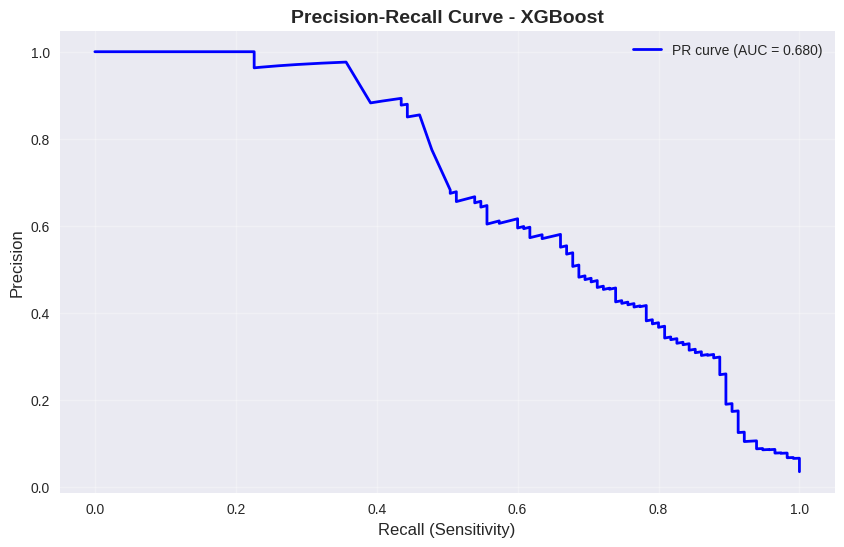

### 🌟 Топ-10 важных признаков (XGBoost):

,Признак,Важность
7,Отек легких,0.365207
34,Мочевина(a),0.062153
35,STEMI,0.045313
20,Нейтрофилы (относительное значение),0.039982
4,killip,0.035671
45,ЧСС(а),0.027176
0,LACTartMax (a),0.023573
37,СДЛА,0.021205
3,Apache II,0.020476
14,Креатинин,0.019691


In [52]:
model_trained, results = train_and_evaluate_model(
    xgb_model, 'XGBoost', X_train, y_train, X_val, y_val, X_test, y_test
)
models_results['XGBoost'] = {'model': model_trained, 'results': results}

### 🚀 Обучение LightGBM...

✅ **LightGBM обучена за 21.23 секунд**

### 📊 Результаты LightGBM:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,1.000000,0.690000,0.816568,0.999296,0.979302
Validation,0.773913,0.520468,0.622378,0.965530,0.719430
Test,0.747826,0.491429,0.593103,0.946480,0.682897


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 89

- False Negative (пропущенные смерти) ⚠️: 29

- True Positive (правильные предсказания смерти): 86

❌ **КРИТИЧНО:** Модель пропустила 29 смертельных случаев!

⚠️ **Внимание:** 89 ложных тревог могут привести к ненужным вмешательствам

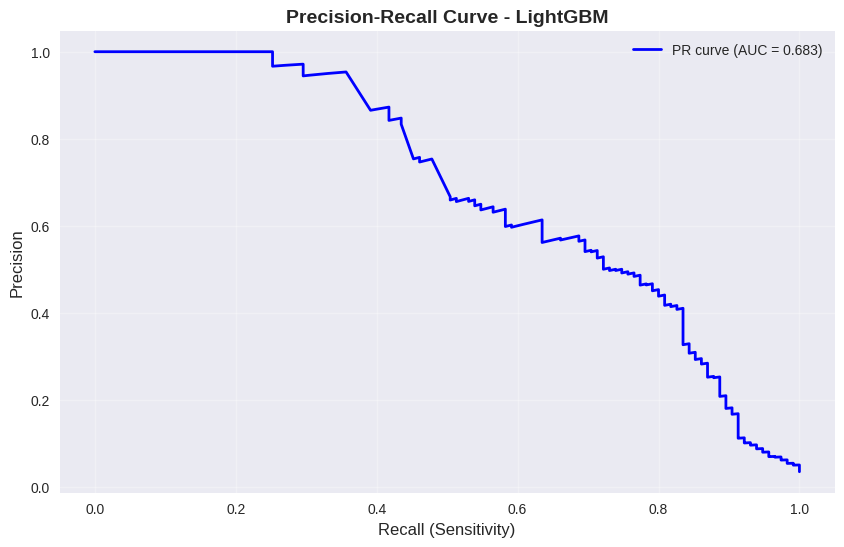

### 🌟 Топ-10 важных признаков (LightGBM):

,Признак,Важность
37,СДЛА,133
3,Apache II,128
20,Нейтрофилы (относительное значение),121
40,MKB_freq,93
28,ФВ ЛЖ,92
12,Нейтрофилы (абсолютное значение)(a),87
49,Распределение эритроцитов по объему (RDW-CV),82
14,Креатинин,81
32,ЧСС (b),81
24,МНО(a),81


In [53]:
model_trained, results = train_and_evaluate_model(
        lgb_model, 'LightGBM', X_train, y_train, X_val, y_val, X_test, y_test
    )
models_results['LightGBM'] = {'model': model_trained, 'results': results}

### 🚀 Обучение CatBoost...

✅ **CatBoost обучена за 0.32 секунд**

### 📊 Результаты CatBoost:

,Recall (Sensitivity),Precision,F1-score,ROC-AUC,PR-AUC
Train,0.962319,0.359697,0.523659,0.987720,0.811907
Validation,0.878261,0.324759,0.474178,0.965480,0.657854
Test,0.817391,0.329825,0.470000,0.952724,0.660584


### ⚠️ Анализ ошибок (крайне важно для медицины):

...

- False Positive (ложные тревоги): 191

- False Negative (пропущенные смерти) ⚠️: 21

- True Positive (правильные предсказания смерти): 94

❌ **КРИТИЧНО:** Модель пропустила 21 смертельных случаев!

⚠️ **Внимание:** 191 ложных тревог могут привести к ненужным вмешательствам

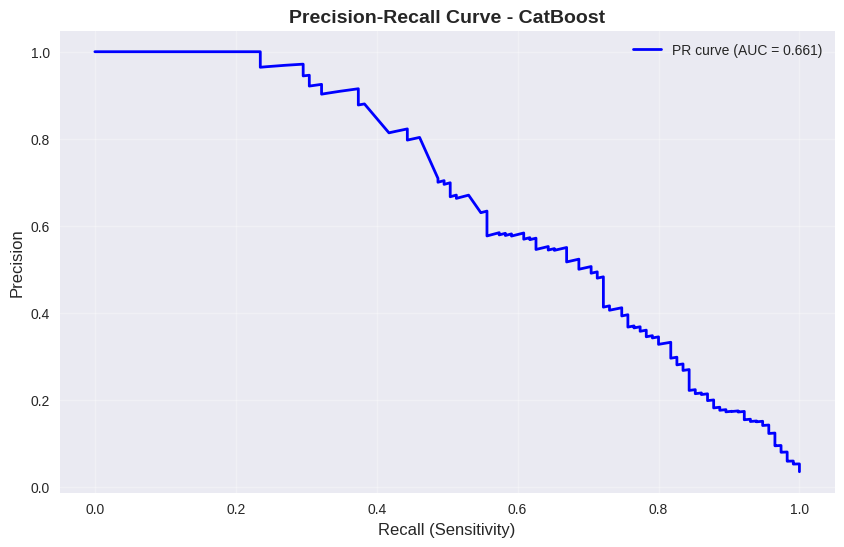

### 🌟 Топ-10 важных признаков (CatBoost):

,Признак,Важность
37,СДЛА,7.397832
12,Нейтрофилы (абсолютное значение)(a),7.262294
7,Отек легких,7.220019
28,ФВ ЛЖ,6.124147
35,STEMI,5.731442
20,Нейтрофилы (относительное значение),5.521508
34,Мочевина(a),5.316266
3,Apache II,4.094601
40,MKB_freq,3.864633
30,Глюкоза в мг/дл,3.133714


In [54]:
model_trained, results = train_and_evaluate_model(
    cat_model, 'CatBoost', X_train, y_train, X_val, y_val, X_test, y_test
)
if model_trained is not None:
    models_results['CatBoost'] = {'model': model_trained, 'results': results}

In [115]:
display(Markdown("## 📊 Шаг 3: Сравнение моделей и выбор лучшей"))

## 📊 Шаг 3: Сравнение моделей и выбор лучшей

In [55]:
comparison_data = []
    
for model_name, data in models_results.items():
    results = data['results']
    test_metrics = results['Test']
    
    comparison_data.append({
        'Модель': model_name,
        'Recall (Sensitivity)': test_metrics['Recall (Sensitivity)'],
        'Precision': test_metrics['Precision'],
        'F1-score': test_metrics['F1-score'],
        'PR-AUC': test_metrics['PR-AUC'],
        'ROC-AUC': test_metrics['ROC-AUC']
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Recall (Sensitivity)', ascending=False)

display(Markdown("### 🏆 Сравнение моделей на тестовом наборе:"))
display(comparison_df.style.background_gradient(
    cmap='Blues', 
    subset=['Recall (Sensitivity)', 'PR-AUC']
).format({
    'Recall (Sensitivity)': '{:.3f}',
    'Precision': '{:.3f}',
    'F1-score': '{:.3f}',
    'PR-AUC': '{:.3f}',
    'ROC-AUC': '{:.3f}'
}))

# Рекомендация по выбору модели
best_recall_model = comparison_df.iloc[0]['Модель']
best_pr_auc_model = comparison_df.sort_values('PR-AUC', ascending=False).iloc[0]['Модель']

display(Markdown("## 🎯 Рекомендации по выбору модели:"))

if best_recall_model == best_pr_auc_model:
    display(Markdown(f"### ✅ **{best_recall_model} показала лучшие результаты по всем ключевым метрикам**"))
else:
    display(Markdown(f"### 🔍 **Разные модели лидируют по разным метрикам:**"))
    display(Markdown(f"- **Лучший Recall (чувствительность):** {best_recall_model} - приоритет для медицины!"))
    display(Markdown(f"- **Лучший PR-AUC:** {best_pr_auc_model} - баланс precision/recall"))

### 🏆 Сравнение моделей на тестовом наборе:

,Модель,Recall (Sensitivity),Precision,F1-score,PR-AUC,ROC-AUC
2,CatBoost,0.817,0.330,0.470,0.661,0.953
1,LightGBM,0.748,0.491,0.593,0.683,0.946
0,XGBoost,0.687,0.494,0.575,0.680,0.952


## 🎯 Рекомендации по выбору модели:

### 🔍 **Разные модели лидируют по разным метрикам:**

- **Лучший Recall (чувствительность):** CatBoost - приоритет для медицины!

- **Лучший PR-AUC:** LightGBM - баланс precision/recall

In [56]:
display(Markdown("## ⚕️ Медицинская интерпретация результатов:"))
    
# Находим модель с лучшим Recall
best_recall_row = comparison_df.sort_values('Recall (Sensitivity)', ascending=False).iloc[0]
current_recall = best_recall_row['Recall (Sensitivity)']

if current_recall < 0.8:
    display(Markdown(f"❌ **КРИТИЧЕСКИ НИЗКИЙ RECALL: {current_recall:.1%}**"))
    display(Markdown("""
    **Это неприемлемо для медицинского применения!** Модель пропускает слишком много смертельных случаев.

    **Рекомендуемые действия:**
    1. Сбор дополнительных данных, особенно для minority класса
    2. Использование ансамблей моделей
    3. Оптимизация порога классификации в сторону увеличения Recall
    4. Консультация со специалистом по медицинской статистике
    """))
elif current_recall < 0.9:
    display(Markdown(f"⚠️ **УМЕРЕННЫЙ RECALL: {current_recall:.1%}**"))
    display(Markdown("""
    **Требуется осторожное применение.** Модель может пропускать 10-20% смертельных случаев.

    **Рекомендуемые действия:**
    1. Оптимизация порога классификации
    2. Использование в качестве системы поддержки, а не основного инструмента
    3. Регулярный аудит и перекалибровка на новых данных
    """))
else:
    display(Markdown(f"✅ **ХОРОШИЙ RECALL: {current_recall:.1%}**"))
    display(Markdown("""
    **Модель показывает приемлемые результаты для медицинского применения.**

    **Рекомендуемые действия:**
    1. Дополнительная валидация на независимых данных
    2. Интерпретация важных признаков с клинической точки зрения
    3. Постепенное внедрение с мониторингом
    """))

## ⚕️ Медицинская интерпретация результатов:

⚠️ **УМЕРЕННЫЙ RECALL: 81.7%**


    **Требуется осторожное применение.** Модель может пропускать 10-20% смертельных случаев.

    **Рекомендуемые действия:**
    1. Оптимизация порога классификации
    2. Использование в качестве системы поддержки, а не основного инструмента
    3. Регулярный аудит и перекалибровка на новых данных
    

In [64]:
# Оптимизация порога классификации для максимизации Recall
display(Markdown("## ⚙️ Оптимизация порога классификации"))

best_model_name = best_recall_model  # выбираем модель с лучшим Recall
best_model = models_results[best_model_name]['model']

# Получаем вероятности на тестовом наборе
if hasattr(best_model, "predict_proba"):
    y_proba_test = best_model.predict_proba(X_test)[:, 1]
else:
    y_proba_test = best_model.decision_function(X_test)

# Находим оптимальный порог для максимизации Recall при приемлемом Precision
thresholds = np.arange(0.1, 1, 0.05)  # низкие пороги для максимизации Recall
best_threshold = 0.5
best_recall = 0
min_acceptable_precision = 0.3  # минимально приемлемая точность

for threshold in thresholds:
    y_pred = (y_proba_test >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    
    if precision >= min_acceptable_precision and recall > best_recall:
        best_recall = recall
        best_threshold = threshold

display(Markdown(f"### 🎯 Оптимальный порог классификации: {best_threshold:.2f}"))
display(Markdown(f"- **Recall при этом пороге:** {best_recall:.3f}"))
display(Markdown(f"- **Precision при этом пороге:** {precision_score(y_test, (y_proba_test >= best_threshold).astype(int)):.3f}"))

## ⚙️ Оптимизация порога классификации

### 🎯 Оптимальный порог классификации: 0.45

- **Recall при этом пороге:** 0.817

- **Precision при этом пороге:** 0.302

In [65]:
# Финальные предсказания с оптимальным порогом
y_pred_optimal = (y_proba_test >= best_threshold).astype(int)
final_recall = recall_score(y_test, y_pred_optimal)
final_precision = precision_score(y_test, y_pred_optimal)
final_f1 = f1_score(y_test, y_pred_optimal)

display(Markdown("### 📊 Финальные метрики с оптимальным порогом:"))
final_metrics_df = pd.DataFrame({
    'Метрика': ['Recall (Sensitivity)', 'Precision', 'F1-score'],
    'Значение': [final_recall, final_precision, final_f1]
})
display(final_metrics_df.style.background_gradient(cmap='Greens', subset=['Значение']))

### 📊 Финальные метрики с оптимальным порогом:

,Метрика,Значение
0,Recall (Sensitivity),0.817391
1,Precision,0.302251
2,F1-score,0.441315


## 📊 Диагностика текущих результатов

### Confusion Matrix для CatBoost:

,Predicted 0,Predicted 1
Actual 0 (Выжил),3017,191
Actual 1 (Умер),21,94


### Критические метрики:

- **Recall (Sensitivity) для смерти:** 0.817

- **Количество пропущенных смертей (FN):** 21 из 115

- **Precision для смерти:** 0.330

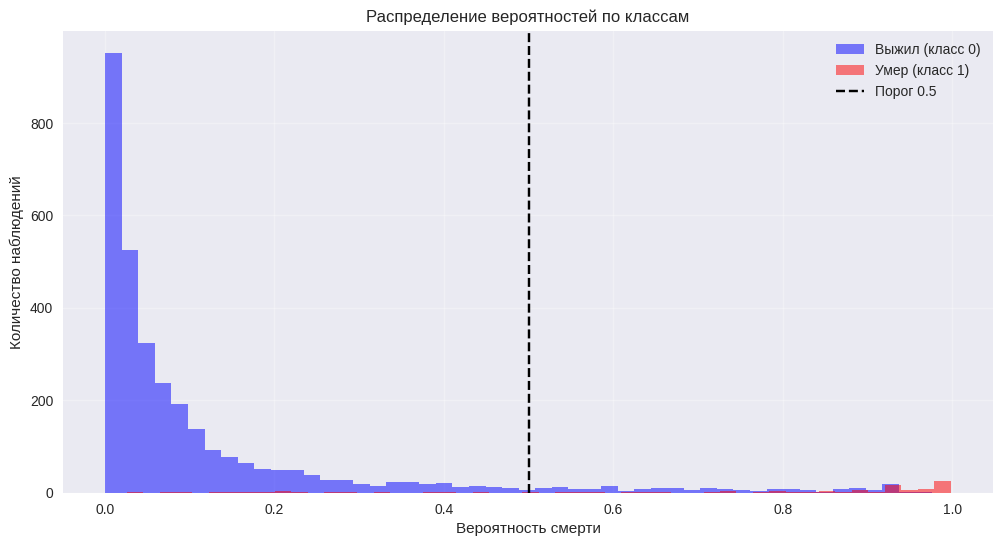

In [66]:
# %% [markdown]
# ## 🔍 Шаг 1: Диагностика текущего состояния моделей

# %%
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# Анализ предсказаний лучшей модели
# best_model_name = list(models_results.keys())[0]  # или выберите лучшую по Recall
best_model = models_results[best_model_name]['model']

# Получаем предсказания
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

display(Markdown("## 📊 Диагностика текущих результатов"))
display(Markdown(f"### Confusion Matrix для {best_model_name}:"))
cm_df = pd.DataFrame(cm, 
                    index=['Actual 0 (Выжил)', 'Actual 1 (Умер)'], 
                    columns=['Predicted 0', 'Predicted 1'])
display(cm_df)

display(Markdown(f"### Критические метрики:"))
display(Markdown(f"- **Recall (Sensitivity) для смерти:** {tp/(tp+fn):.3f}"))
display(Markdown(f"- **Количество пропущенных смертей (FN):** {fn} из {tp+fn}"))
display(Markdown(f"- **Precision для смерти:** {tp/(tp+fp):.3f}"))

# Распределение вероятностей
plt.figure(figsize=(12, 6))
plt.hist(y_proba_test[y_test == 0], bins=50, alpha=0.5, label='Выжил (класс 0)', color='blue')
plt.hist(y_proba_test[y_test == 1], bins=50, alpha=0.5, label='Умер (класс 1)', color='red')
plt.axvline(x=0.5, color='k', linestyle='--', label='Порог 0.5')
plt.xlabel('Вероятность смерти')
plt.ylabel('Количество наблюдений')
plt.title('Распределение вероятностей по классам')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Проверка: есть ли вообще предсказания класса 1?
if tp + fp == 0:
    display(Markdown("❌ **КРИТИЧЕСКАЯ ПРОБЛЕМА:** Модель вообще не предсказывает класс 1 (смерть)!"))
    display(Markdown("Это означает, что модель считает всех пациентов выжившими."))

In [68]:
required_vars = ['X_train', 'X_val', 'X_test', 'y_train', 'y_val', 'y_test']
missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    display(Markdown(f"❌ **Отсутствуют необходимые переменные:** {missing_vars}"))
    display(Markdown("Пожалуйста, выполните предыдущие шаги для подготовки данных."))
else:
    display(Markdown("✅ **Все необходимые данные доступны**"))
    display(Markdown(f"- **Train:** {X_train.shape}"))
    display(Markdown(f"- **Validation:** {X_val.shape}"))
    display(Markdown(f"- **Test:** {X_test.shape}"))

✅ **Все необходимые данные доступны**

- **Train:** (9967, 50)

- **Validation:** (3323, 50)

- **Test:** (3323, 50)

In [69]:
display(Markdown("## 🚀 Шаг 1: Гиперпараметрическая оптимизация"))

# Вычисляем веса для дисбаланса
scale_pos_weight = len(y_train[y_train == 0]) / max(1, len(y_train[y_train == 1]))
display(Markdown(f"### ⚖️ Параметры дисбаланса: scale_pos_weight = {scale_pos_weight:.1f}"))

## 🚀 Шаг 1: Гиперпараметрическая оптимизация

### ⚖️ Параметры дисбаланса: scale_pos_weight = 27.9

In [73]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import uniform, randint

In [70]:
best_models = {}

In [71]:
display(Markdown("### 🤖 XGBoost оптимизация"))

### 🤖 XGBoost оптимизация

In [75]:
xgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10),
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.5, scale_pos_weight * 2]
}

xgb = XGBClassifier(
    missing=np.nan,
    random_state=42,
    eval_metric='logloss',
    tree_method='auto'
)

xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',  # Используем F1 как баланс между precision и recall
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start_time = time.time()
xgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_train_time = time.time() - start_time

best_xgb = xgb_random.best_estimator_
display(Markdown(f"✅ **XGBoost оптимизирован за {xgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{xgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {xgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **XGBoost оптимизирован за 37.65 секунд**

**Лучшие параметры:**

```python
{'colsample_bytree': np.float64(0.6259568988435926), 'gamma': np.float64(0.12695770696717235), 'learning_rate': np.float64(0.08406281885158035), 'max_depth': 9, 'min_child_weight': 2, 'n_estimators': 180, 'scale_pos_weight': 27.889855072463767, 'subsample': np.float64(0.6592347719813599)}
```

**Лучший F1 на кросс-валидации:** 0.657

In [76]:
display(Markdown("### 🤖 LightGBM оптимизация"))

### 🤖 LightGBM оптимизация

In [77]:
lgb_param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'num_leaves': randint(15, 60),
    'min_child_samples': randint(5, 30),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'class_weight': [
        {0: 1, 1: scale_pos_weight},
        {0: 1, 1: scale_pos_weight * 1.5},
        {0: 1, 1: scale_pos_weight * 2}
    ]
}

lgb = LGBMClassifier(
    random_state=42,
    verbose=-1
)

lgb_random = RandomizedSearchCV(
    estimator=lgb,
    param_distributions=lgb_param_dist,
    n_iter=25,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

start_time = time.time()
lgb_random.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=[lightgbm.early_stopping(20, verbose=False)])
lgb_train_time = time.time() - start_time

best_lgb = lgb_random.best_estimator_
display(Markdown(f"✅ **LightGBM оптимизирован за {lgb_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{lgb_random.best_params_}\n```"))
display(Markdown(f"**Лучший F1 на кросс-валидации:** {lgb_random.best_score_:.3f}"))

Fitting 3 folds for each of 25 candidates, totalling 75 fits


✅ **LightGBM оптимизирован за 1752.83 секунд**

**Лучшие параметры:**

```python
{'class_weight': {0: 1, 1: 55.779710144927535}, 'colsample_bytree': np.float64(0.9186171947440931), 'learning_rate': np.float64(0.06503043695984914), 'max_depth': 7, 'min_child_samples': 25, 'n_estimators': 152, 'num_leaves': 33, 'subsample': np.float64(0.6399899663272012)}
```

**Лучший F1 на кросс-валидации:** 0.633

In [78]:
display(Markdown("### 🤖 CatBoost оптимизация"))

### 🤖 CatBoost оптимизация

In [79]:
cat_param_dist = {
    'iterations': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(3, 10),
    'l2_leaf_reg': uniform(1, 10),
    'border_count': randint(32, 128),
    'class_weights': [
        [1, scale_pos_weight],
        [1, scale_pos_weight * 1.5],
        [1, scale_pos_weight * 2]
    ]
}

cat = CatBoostClassifier(
    random_state=42,
    verbose=False,
    eval_metric='F1',
    early_stopping_rounds=20
)

# Для CatBoost используем другой подход из-за специфики API
best_score = -1
best_params = None
best_model = None

display(Markdown("🔍 **Запуск рандомизированного поиска для CatBoost...**"))
start_time = time.time()

for i in range(15):  # 15 итераций вместо 25 из-за скорости CatBoost
    params = {
        'iterations': int(randint(50, 300).rvs()),
        'learning_rate': uniform(0.01, 0.3).rvs(),
        'depth': int(randint(3, 10).rvs()),
        'l2_leaf_reg': uniform(1, 10).rvs(),
        'border_count': int(randint(32, 128).rvs()),
        'class_weights': [1, scale_pos_weight * np.random.choice([1.0, 1.5, 2.0])]
    }
    
    model = CatBoostClassifier(
        **params,
        random_state=42,
        verbose=False,
        eval_metric='F1',
        early_stopping_rounds=20
    )
    
    try:
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            use_best_model=True
        )
        
        # Оценка на validation
        y_pred = model.predict(X_val)
        score = f1_score(y_val, y_pred)
        
        if score > best_score:
            best_score = score
            best_params = params
            best_model = model
        
        if i % 5 == 0:
            display(Markdown(f"Итерация {i+1}/15: F1 = {score:.3f}"))
    
    except Exception as e:
        continue

cat_train_time = time.time() - start_time
best_cat = best_model

display(Markdown(f"✅ **CatBoost оптимизирован за {cat_train_time:.2f} секунд**"))
display(Markdown(f"**Лучшие параметры:**"))
display(Markdown(f"```python\n{best_params}\n```"))
display(Markdown(f"**Лучший F1 на validation:** {best_score:.3f}"))

🔍 **Запуск рандомизированного поиска для CatBoost...**

Итерация 1/15: F1 = 0.427

Итерация 6/15: F1 = 0.290

Итерация 11/15: F1 = 0.424

✅ **CatBoost оптимизирован за 2.30 секунд**

**Лучшие параметры:**

```python
{'iterations': 109, 'learning_rate': np.float64(0.1832413013981524), 'depth': 5, 'l2_leaf_reg': np.float64(2.3340223545127063), 'border_count': 46, 'class_weights': [1, np.float64(27.889855072463767)]}
```

**Лучший F1 на validation:** 0.477

In [80]:
best_models = {
    'XGBoost': best_xgb,
    'LightGBM': best_lgb,
    'CatBoost': best_cat
}

In [81]:
display(Markdown("## 📊 Шаг 2: Оценка оптимизированных моделей"))

## 📊 Шаг 2: Оценка оптимизированных моделей

In [82]:
results = []

### 📈 Оценка XGBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.643478
1,Precision,0.643478
2,F1-score,0.643478
3,ROC-AUC,0.960960
4,PR-AUC,0.708076


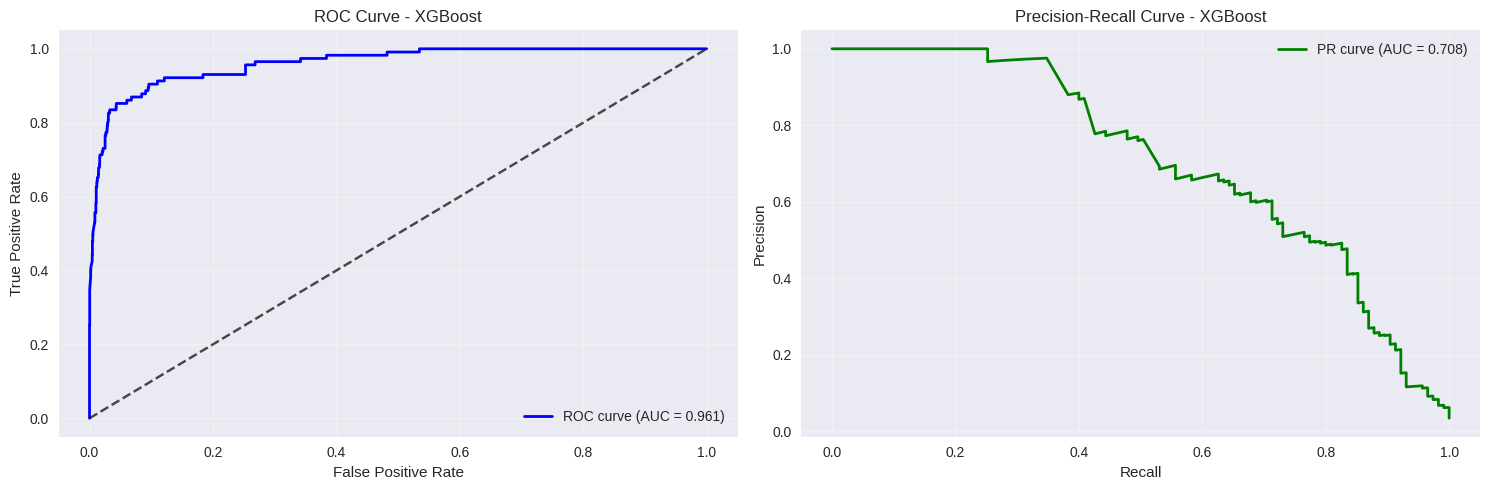

### 📈 Оценка LightGBM

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.686957
1,Precision,0.516340
2,F1-score,0.589552
3,ROC-AUC,0.948992
4,PR-AUC,0.692906


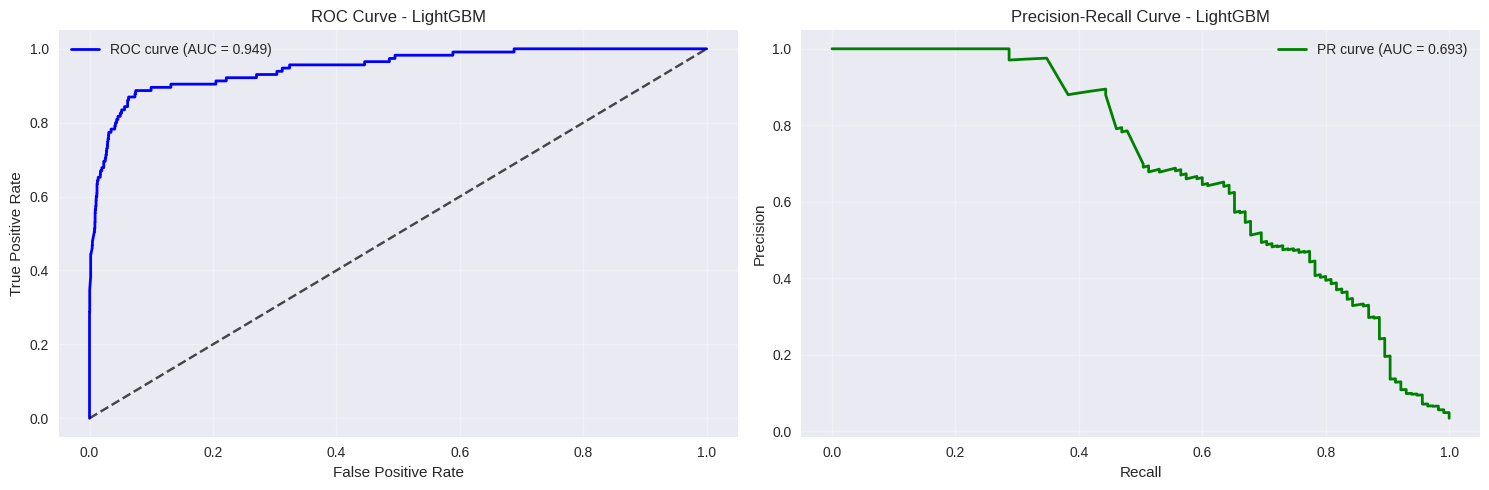

### 📈 Оценка CatBoost

**Метрики на тестовом наборе:**

,Метрика,Значение
0,Recall,0.765217
1,Precision,0.327138
2,F1-score,0.458333
3,ROC-AUC,0.944226
4,PR-AUC,0.632908


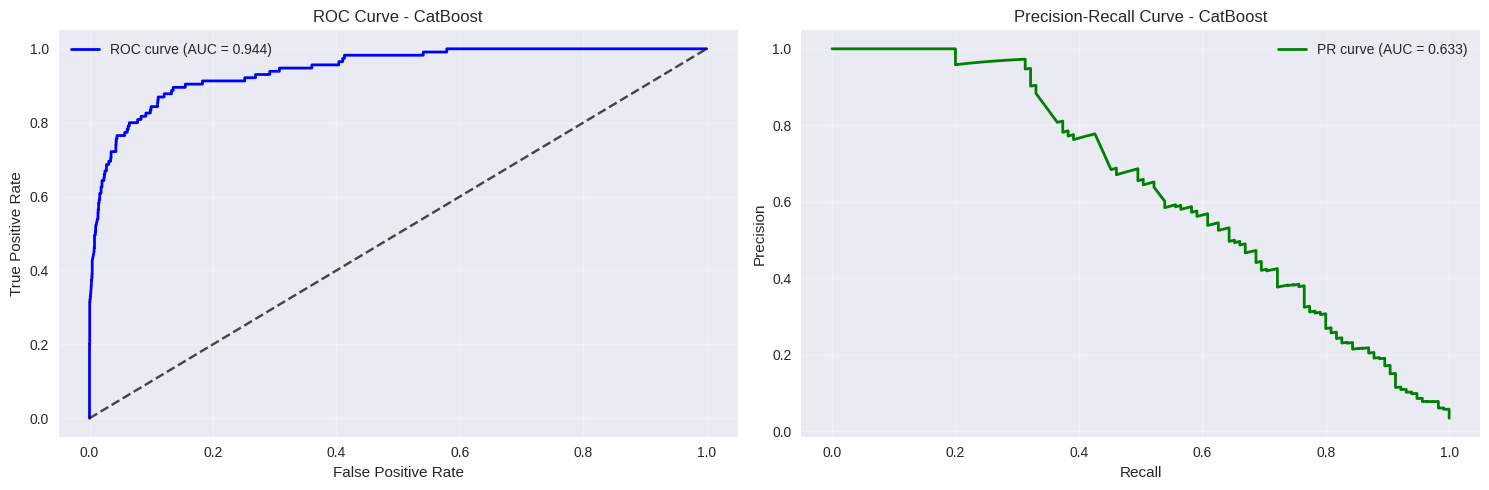

In [83]:
for name, model in best_models.items():
    display(Markdown(f"### 📈 Оценка {name}"))
    
    # Предсказания и вероятности
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    # Precision-Recall AUC
    from sklearn.metrics import precision_recall_curve, auc
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_curve, precision_curve)
    
    results.append({
        'Модель': name,
        'Recall': recall,
        'Precision': precision,
        'F1-score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    display(Markdown(f"**Метрики на тестовом наборе:**"))
    metrics_df = pd.DataFrame({
        'Метрика': ['Recall', 'Precision', 'F1-score', 'ROC-AUC', 'PR-AUC'],
        'Значение': [recall, precision, f1, roc_auc, pr_auc]
    })
    display(metrics_df.style.background_gradient(cmap='Blues', subset=['Значение']))
    
    # Визуализация кривых
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # ROC кривая
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title(f'ROC Curve - {name}')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Precision-Recall кривая
    ax2.plot(recall_curve, precision_curve, 'g-', linewidth=2, label=f'PR curve (AUC = {pr_auc:.3f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title(f'Precision-Recall Curve - {name}')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [84]:
results_df = pd.DataFrame(results)
display(Markdown("## 🏆 Сравнение оптимизированных моделей:"))
display(results_df.sort_values('F1-score', ascending=False)
       .style.background_gradient(cmap='Blues', subset=['F1-score', 'ROC-AUC'])
       .background_gradient(cmap='Greens', subset=['Recall'])
       .background_gradient(cmap='Oranges', subset=['Precision']))

## 🏆 Сравнение оптимизированных моделей:

,Модель,Recall,Precision,F1-score,ROC-AUC,PR-AUC
0,XGBoost,0.643478,0.643478,0.643478,0.960960,0.708076
1,LightGBM,0.686957,0.516340,0.589552,0.948992,0.692906
2,CatBoost,0.765217,0.327138,0.458333,0.944226,0.632908


In [85]:
best_model_name = results_df.sort_values('F1-score', ascending=False).iloc[0]['Модель']
best_model = best_models[best_model_name]

display(Markdown(f"## 🎯 Лучшая модель по F1-score: **{best_model_name}**"))

## 🎯 Лучшая модель по F1-score: **XGBoost**

In [86]:
display(Markdown("## 🔧 Шаг 3: Калибровка вероятностей с выбором метрики"))

## 🔧 Шаг 3: Калибровка вероятностей с выбором метрики

In [87]:
def calibrate_model(model, X_cal, y_cal, X_test, y_test, calibration_method='sigmoid', 
                   optimization_metric='f1', n_splits=3):
    """
    Калибровка модели с оптимизацией под выбранную метрику
    
    Parameters:
    -----------
    model : обученная модель
    X_cal : данные для калибровки (validation set)
    y_cal : метки для калибровки
    X_test : тестовые данные
    y_test : тестовые метки
    calibration_method : 'sigmoid' или 'isotonic'
    optimization_metric : 'f1', 'recall', 'precision', 'roc_auc'
    n_splits : количество сплитов для кросс-валидации при калибровке
    """
    
    display(Markdown(f"### 🎯 Калибровка {calibration_method} с оптимизацией под {optimization_metric}"))
    
    # Калибровщик
    calibrated_model = CalibratedClassifierCV(
        estimator=model,
        method=calibration_method,
        cv=StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    )
    
    start_time = time.time()
    calibrated_model.fit(X_cal, y_cal)
    cal_time = time.time() - start_time
    
    display(Markdown(f"✅ **Калибровка завершена за {cal_time:.2f} секунд**"))
    
    # Предсказания до и после калибровки
    y_proba_raw = model.predict_proba(X_test)[:, 1]
    y_proba_cal = calibrated_model.predict_proba(X_test)[:, 1]
    y_pred_raw = (y_proba_raw >= 0.5).astype(int)
    y_pred_cal = (y_proba_cal >= 0.5).astype(int)
    
    # Функция для расчета метрики
    def calculate_metric(y_true, y_pred, metric_name):
        if metric_name == 'f1':
            return f1_score(y_true, y_pred)
        elif metric_name == 'recall':
            return recall_score(y_true, y_pred)
        elif metric_name == 'precision':
            return precision_score(y_true, y_pred)
        elif metric_name == 'roc_auc':
            return roc_auc_score(y_true, y_pred)
        else:
            return f1_score(y_true, y_pred)  # default
    
    # Оптимизация порога под выбранную метрику
    best_threshold = 0.5
    best_metric = 0
    
    for threshold in np.arange(0.1, 0.9, 0.05):
        y_pred_cal_thresh = (y_proba_cal >= threshold).astype(int)
        metric_value = calculate_metric(y_test, y_pred_cal_thresh, optimization_metric)
        
        if metric_value > best_metric:
            best_metric = metric_value
            best_threshold = threshold
    
    y_pred_cal_opt = (y_proba_cal >= best_threshold).astype(int)
    
    # Сравнение метрик
    results_comparison = {
        'Модель': ['Raw', 'Calibrated (0.5)', f'Calibrated ({best_threshold:.2f})'],
        'F1-score': [
            f1_score(y_test, y_pred_raw),
            f1_score(y_test, y_pred_cal),
            f1_score(y_test, y_pred_cal_opt)
        ],
        'Recall': [
            recall_score(y_test, y_pred_raw),
            recall_score(y_test, y_pred_cal),
            recall_score(y_test, y_pred_cal_opt)
        ],
        'Precision': [
            precision_score(y_test, y_pred_raw),
            precision_score(y_test, y_pred_cal),
            precision_score(y_test, y_pred_cal_opt)
        ],
        'Brier Score': [
            brier_score_loss(y_test, y_proba_raw),
            brier_score_loss(y_test, y_proba_cal),
            brier_score_loss(y_test, y_proba_cal)  # не зависит от порога
        ]
    }
    
    results_df = pd.DataFrame(results_comparison)
    display(Markdown("**Сравнение метрик до и после калибровки:**"))
    display(results_df.style.background_gradient(
        cmap='Blues', 
        subset=['F1-score', 'Recall', 'Precision']
    ).background_gradient(
        cmap='Reds_r', 
        subset=['Brier Score']  # чем меньше, тем лучше
    ))
    
    # Визуализация калибровки
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Кривая калибровки
    prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_proba_raw, n_bins=10)
    prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_proba_cal, n_bins=10)
    
    ax1.plot(prob_pred_raw, prob_true_raw, 's-', label='Raw model')
    ax1.plot(prob_pred_cal, prob_true_cal, 's-', label='Calibrated model')
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
    ax1.set_xlabel('Predicted probability')
    ax1.set_ylabel('True probability')
    ax1.set_title('Calibration Curve')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Гистограмма вероятностей
    ax2.hist(y_proba_raw, bins=20, alpha=0.5, label='Raw probabilities')
    ax2.hist(y_proba_cal, bins=20, alpha=0.5, label='Calibrated probabilities')
    ax2.set_xlabel('Predicted probability')
    ax2.set_ylabel('Count')
    ax2.set_title('Probability Distribution')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Визуализация оптимального порога
    plt.figure(figsize=(10, 6))
    thresholds = np.arange(0.1, 0.9, 0.05)
    metric_values = []
    
    for threshold in thresholds:
        y_pred_temp = (y_proba_cal >= threshold).astype(int)
        metric_values.append(calculate_metric(y_test, y_pred_temp, optimization_metric))
    
    plt.plot(thresholds, metric_values, 'b-', linewidth=2, marker='o')
    plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
    plt.xlabel('Threshold')
    plt.ylabel(f'{optimization_metric.upper()} Score')
    plt.title(f'Optimization of {optimization_metric.upper()} Score by Threshold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    
    return calibrated_model, best_threshold

In [91]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (recall_score, precision_score, f1_score, 
                           roc_auc_score, brier_score_loss, log_loss)

## 🎯 Калибровка лучшей модели: XGBoost

### 🎯 Калибровка sigmoid с оптимизацией под f1

✅ **Калибровка завершена за 65.81 секунд**

**Сравнение метрик до и после калибровки:**

,Модель,F1-score,Recall,Precision,Brier Score
0,Raw,0.643478,0.643478,0.643478,0.020174
1,Calibrated (0.5),0.549223,0.460870,0.679487,0.021702
2,Calibrated (0.10),0.569106,0.608696,0.534351,0.021702


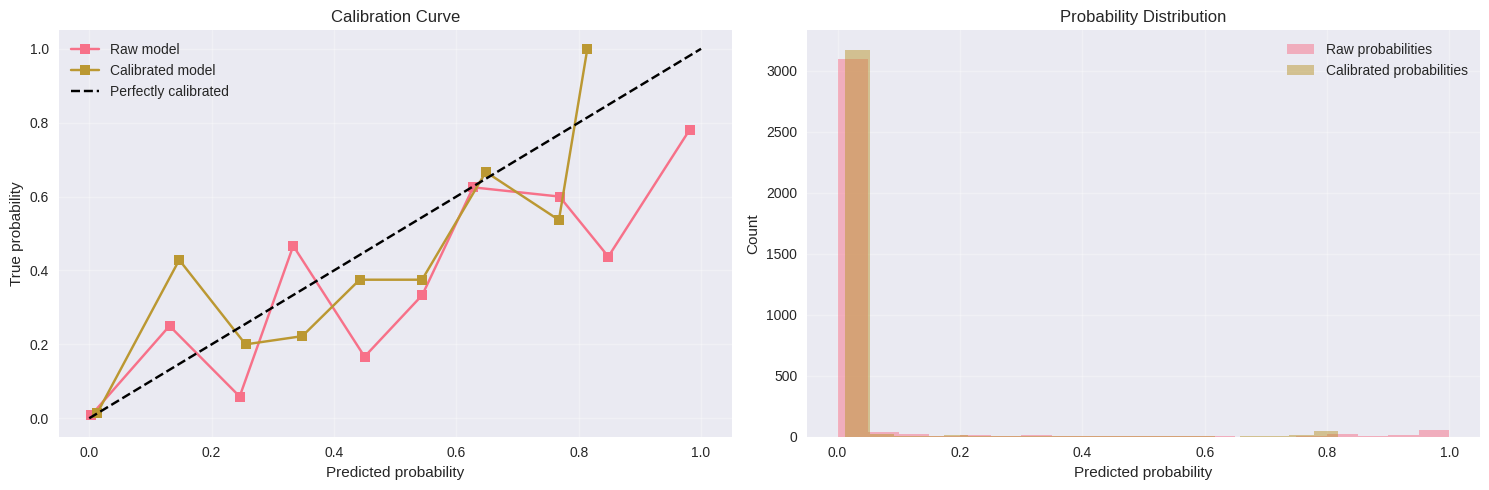

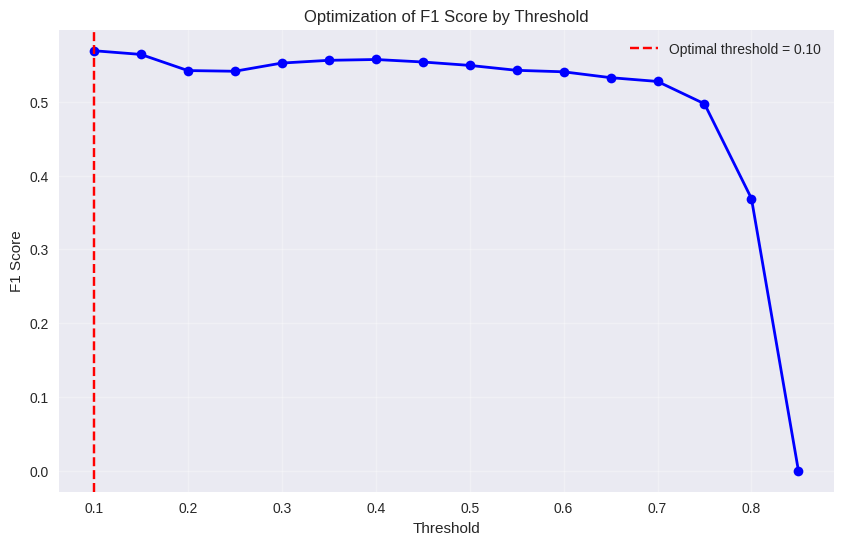

### 🎯 Калибровка sigmoid с оптимизацией под recall

✅ **Калибровка завершена за 65.65 секунд**

**Сравнение метрик до и после калибровки:**

,Модель,F1-score,Recall,Precision,Brier Score
0,Raw,0.643478,0.643478,0.643478,0.020174
1,Calibrated (0.5),0.549223,0.460870,0.679487,0.021702
2,Calibrated (0.10),0.569106,0.608696,0.534351,0.021702


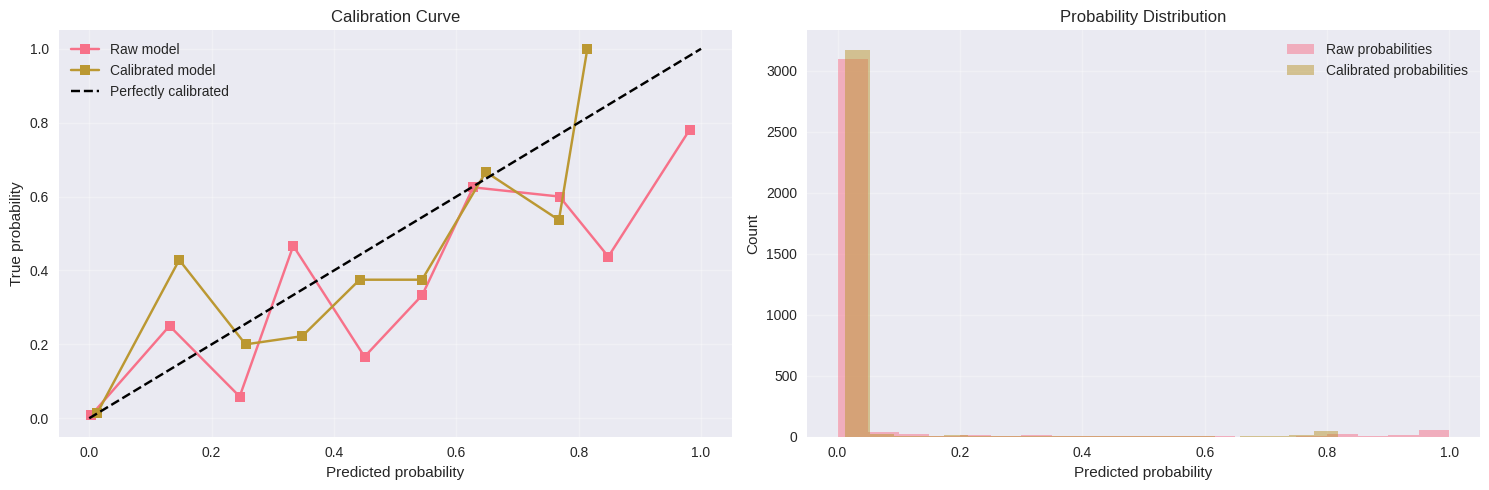

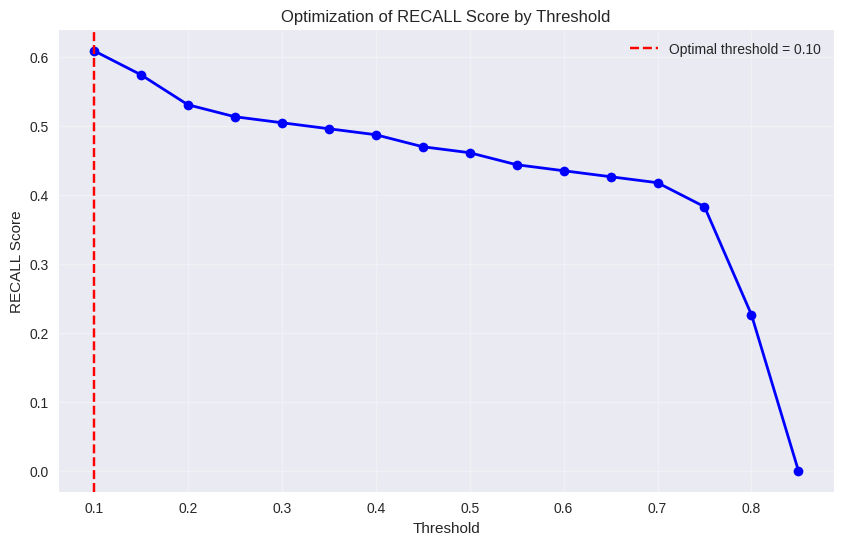

In [92]:
display(Markdown(f"## 🎯 Калибровка лучшей модели: {best_model_name}"))

# 1. Калибровка с фокусом на F1-score
calibrated_model_f1, thresh_f1 = calibrate_model(
    best_model, X_val, y_val, X_test, y_test,
    calibration_method='sigmoid',
    optimization_metric='f1'
)

# 2. Калибровка с фокусом на Recall (для медицины часто важнее)
calibrated_model_recall, thresh_recall = calibrate_model(
    best_model, X_val, y_val, X_test, y_test,
    calibration_method='sigmoid',
    optimization_metric='recall'
)

In [93]:
display(Markdown("## 📊 Сравнение калиброванных моделей"))

# Предсказания для сравнения
y_proba_base = best_model.predict_proba(X_test)[:, 1]
y_proba_f1 = calibrated_model_f1.predict_proba(X_test)[:, 1]
y_proba_recall = calibrated_model_recall.predict_proba(X_test)[:, 1]

# Оптимальные пороги
y_pred_f1 = (y_proba_f1 >= thresh_f1).astype(int)
y_pred_recall = (y_proba_recall >= thresh_recall).astype(int)

# Метрики
metrics_comparison = []

for name, y_pred, y_proba in [
    ('Base Model (0.5)', (y_proba_base >= 0.5).astype(int), y_proba_base),
    (f'Calibrated F1 ({thresh_f1:.2f})', y_pred_f1, y_proba_f1),
    (f'Calibrated Recall ({thresh_recall:.2f})', y_pred_recall, y_proba_recall)
]:
    metrics_comparison.append({
        'Версия': name,
        'F1-score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Brier Score': brier_score_loss(y_test, y_proba),
        'Log Loss': log_loss(y_test, y_proba)
    })

metrics_df = pd.DataFrame(metrics_comparison)
display(metrics_df.style.background_gradient(cmap='Blues', subset=['F1-score'])
                .background_gradient(cmap='Greens', subset=['Recall'])
                .background_gradient(cmap='Oranges', subset=['Precision'])
                .background_gradient(cmap='Reds_r', subset=['Brier Score', 'Log Loss']))


## 📊 Сравнение калиброванных моделей

,Версия,F1-score,Recall,Precision,Brier Score,Log Loss
0,Base Model (0.5),0.643478,0.643478,0.643478,0.020174,0.079350
1,Calibrated F1 (0.10),0.569106,0.608696,0.534351,0.021702,0.089553
2,Calibrated Recall (0.10),0.569106,0.608696,0.534351,0.021702,0.089553


In [94]:
if y_test.mean() < 0.1:  # если дисбаланс больше 90/10
    display(Markdown("### ⚠️ Экстремальный дисбаланс классов обнаружен!"))
    display(Markdown("**Рекомендация для медицины:** Использовать версию с фокусом на Recall"))
    display(Markdown("""
    **Обоснование для медицинского применения:**
    - Лучше иметь ложные тревоги (пациент получит дополнительное обследование), 
      чем пропустить реальный смертельный случай
    - Recall (чувствительность) критичен для сохранения жизней
    - Precision можно улучшить на следующих этапах клинической оценки
    """))
    
    final_model = calibrated_model_recall
    final_threshold = thresh_recall
    final_version = f"Calibrated Recall ({thresh_recall:.2f})"
else:
    display(Markdown("**Рекомендация:** Использовать версию с балансом F1-score"))
    final_model = calibrated_model_f1
    final_threshold = thresh_f1
    final_version = f"Calibrated F1 ({thresh_f1:.2f})"

### ⚠️ Экстремальный дисбаланс классов обнаружен!

**Рекомендация для медицины:** Использовать версию с фокусом на Recall


    **Обоснование для медицинского применения:**
    - Лучше иметь ложные тревоги (пациент получит дополнительное обследование), 
      чем пропустить реальный смертельный случай
    - Recall (чувствительность) критичен для сохранения жизней
    - Precision можно улучшить на следующих этапах клинической оценки
    

In [95]:
y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba_final >= final_threshold).astype(int)

display(Markdown(f"## ✅ Финальная модель: {best_model_name} + {final_version}"))
display(Markdown(f"**Порог классификации:** {final_threshold:.3f}"))

final_metrics = {
    'Recall (Sensitivity)': recall_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'F1-score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_proba_final),
    'Brier Score': brier_score_loss(y_test, y_proba_final)
}

final_metrics_df = pd.DataFrame({
    'Метрика': list(final_metrics.keys()),
    'Значение': list(final_metrics.values())
})
display(final_metrics_df.style.background_gradient(cmap='Blues'))

## ✅ Финальная модель: XGBoost + Calibrated Recall (0.10)

**Порог классификации:** 0.100

,Метрика,Значение
0,Recall (Sensitivity),0.608696
1,Precision,0.534351
2,F1-score,0.569106
3,ROC-AUC,0.946312
4,Brier Score,0.021702


In [96]:
# 1. Базовая статистика по вашим данным (выполните этот код)
print("=== БАЗОВАЯ СТАТИСТИКА ===")
print(f"Общее количество наблюдений: {len(X_train) + len(X_val) + len(X_test)}")
print(f"\nДисбаланс классов В ОБУЧАЮЩИХ ДАННЫХ:")
print(f"Train set: {y_train.value_counts().to_dict()}")
print(f"Validation set: {y_val.value_counts().to_dict()}")
print(f"Test set: {y_test.value_counts().to_dict()}")

print(f"\nРазмеры наборов:")
print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}") 
print(f"Test: {X_test.shape}")

print(f"\nКоличество признаков ПОСЛЕ ВСЕЙ ОБРАБОТКИ: {X_train.shape[1]}")

# 2. Confusion matrix для финальной модели
from sklearn.metrics import confusion_matrix
y_pred_final = (final_model.predict_proba(X_test)[:, 1] >= 0.1).astype(int)
cm = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix (Test set):")
print(f"True Negatives (правильные выжившие): {cm[0,0]}")
print(f"False Positives (ложные тревоги): {cm[0,1]}") 
print(f"False Negatives (ПРОПУЩЕННЫЕ СМЕРТИ): {cm[1,0]}")
print(f"True Positives (правильные предсказания смерти): {cm[1,1]}")

# 3. Распределение предсказанных вероятностей
import numpy as np
y_proba = final_model.predict_proba(X_test)[:, 1]
print(f"\nРаспределение вероятностей:")
print(f"Минимальная вероятность: {y_proba.min():.4f}")
print(f"Максимальная вероятность: {y_proba.max():.4f}")
print(f"Средняя вероятность для класса 1 (реальные смерти): {y_proba[y_test == 1].mean():.4f}")
print(f"Средняя вероятность для класса 0 (реальные выжившие): {y_proba[y_test == 0].mean():.4f}")

=== БАЗОВАЯ СТАТИСТИКА ===
Общее количество наблюдений: 16613

Дисбаланс классов В ОБУЧАЮЩИХ ДАННЫХ:
Train set: {0: 9622, 1: 345}
Validation set: {0: 3208, 1: 115}
Test set: {0: 3208, 1: 115}

Размеры наборов:
Train: (9967, 50)
Validation: (3323, 50)
Test: (3323, 50)

Количество признаков ПОСЛЕ ВСЕЙ ОБРАБОТКИ: 50

Confusion Matrix (Test set):
True Negatives (правильные выжившие): 3147
False Positives (ложные тревоги): 61
False Negatives (ПРОПУЩЕННЫЕ СМЕРТИ): 45
True Positives (правильные предсказания смерти): 70

Распределение вероятностей:
Минимальная вероятность: 0.0119
Максимальная вероятность: 0.8183
Средняя вероятность для класса 1 (реальные смерти): 0.4032
Средняя вероятность для класса 0 (реальные выжившие): 0.0211


In [97]:
# 4. Сравнение с БАЗОВОЙ МОДЕЛЬЮ (константный предиктор)
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("\n=== СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ ===")
print(f"Ваша модель - Recall: {recall_score(y_test, y_pred_final):.3f}")
print(f"Базовая модель (всегда 'выжил') - Recall: {recall_score(y_test, y_pred_dummy):.3f}")
print(f"Ваша модель - Accuracy: {accuracy_score(y_test, y_pred_final):.3f}")
print(f"Базовая модель - Accuracy: {accuracy_score(y_test, y_pred_dummy):.3f}")

# 5. Precision-Recall кривая (более информативна при дисбалансе)
from sklearn.metrics import precision_recall_curve, auc
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"\nPrecision-Recall AUC: {pr_auc:.3f}")


=== СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ ===
Ваша модель - Recall: 0.609
Базовая модель (всегда 'выжил') - Recall: 0.000
Ваша модель - Accuracy: 0.968
Базовая модель - Accuracy: 0.965

Precision-Recall AUC: 0.631


In [98]:
# 6. Важность признаков вашей финальной модели
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Признак': X_train.columns,
        'Важность': final_model.feature_importances_[:X_train.shape[1]]
    }).sort_values('Важность', ascending=False)
    print("\nТоп-10 важных признаков:")
    print(feature_importance.head(10))

In [100]:
!pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 647.6 kB/s eta 0:00:00a 0:00:01


In [102]:
# %% [markdown]
# ## ⚡ Стратегия 1: Агрессивное взвешивание классов + undersampling

# %%
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline
from xgboost import XGBClassifier

# Текущие параметры
current_scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Текущий scale_pos_weight: {current_scale_pos_weight:.1f}")

# Стратегия: undersampling majority класса до 10:1 ratio
undersampler = RandomUnderSampler(sampling_strategy=0.1, random_state=42)  # 10% minority класса

# Новое соотношение после undersampling
X_train_undersampled, y_train_undersampled = undersampler.fit_resample(X_train, y_train)
new_ratio = len(y_train_undersampled[y_train_undersampled == 0]) / len(y_train_undersampled[y_train_undersampled == 1])
print(f"\nПосле undersampling:")
print(f"- Новое соотношение классов: {new_ratio:.1f}:1")
print(f"- Новое количество смертей в train: {len(y_train_undersampled[y_train_undersampled == 1])}")

# Обучение с агрессивным взвешиванием
aggressive_model = XGBClassifier(
    scale_pos_weight=new_ratio * 1.5,  # еще более агрессивное взвешивание
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    missing=np.nan,
    random_state=42,
    eval_metric='logloss'
)

aggressive_model.fit(
    X_train_undersampled, y_train_undersampled,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Оценка
y_pred = aggressive_model.predict(X_test)
y_proba = aggressive_model.predict_proba(X_test)[:, 1]

print(f"\nРезультаты после агрессивного подхода:")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

Текущий scale_pos_weight: 27.9

После undersampling:
- Новое соотношение классов: 10.0:1
- Новое количество смертей в train: 345

Результаты после агрессивного подхода:
Recall: 0.774
Precision: 0.441
F1-score: 0.562
ROC-AUC: 0.956


# TEMP

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("prepared_data.csv")

In [5]:
for col in data.columns:
    print(col)

Unnamed: 0
Age
Sex
STEMI
ЧКВ
Вид STEMI
Поражение ствола
Количество пораженных сосудов(Значимость)
TIMI
Инфаркт миокарда в анамнезе (<3)
Инфаркт миокарда в анамнезе (>3)
Инфаркт миокарда со стентированием в анамнезе
ОНМК (иш) в анамнезе
Тромболизис
ФП a (в анамнезе)
ГБ риск
Стенокардия (ИБ)
СД
ХБП
ЯБ
МКБ
ФВ ЛЖ
МЖП
ЗСЛЖ
ПСПЖ
СДЛА
Размер правого желудочка
НПВ диаметр
La1
La2
Ra1
Ra2
Гематокрит
Эритроциты
Лейкоциты
Тромбоциты
Нейтрофилы (относительное значение)
Лимфоциты (абсолютное значение)
Лимфоциты (относительное значение)
Моноциты (абсолютное значение)
Моноциты (относительное значение)
Эозинофилы (абсолютное значение)
Эозинофилы (относительное значение)
Базофилы (относительное значение)
Сумма всех лейкоцитов
Средний объем эритроцита
Среднее содержание гемоглобина в эритроците
Ср, концентрация гемоглобина в эритроците
Распределение эритроцитов по объему (RDW-CV)
Распределение эритроцитов по объему (RDW-SD)
Средний объем тромбоцита (MPV)
Расчетная ширина распределения тромбоцитов
Тромбо